Given a feature set for host atoms ${f_i}$, intermediate host variables ${v_i}$, decoupled models are:

$v_j = \sum_i a_i h_j$, where ${a_i}$ are different for each host element. Then

$y = \sum_i b_i v_j = \sum_i \sum_j b_i a_j h_j$, where $b_i$ is different for each guest and site. 

TODO: Add some TSes from MSR data.
- Fix site detection and such. See TODOs throughout.

In [2]:
import numpy as np
from ase.io import read
from ase.visualize import view
from ase.db import connect
import sys
import pandas as pd
import matplotlib.pyplot as plt
import copy

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection  import train_test_split
from scipy.optimize import least_squares, minimize, basinhopping

# from Helper_SurfEP_DirectFit_Dev import exportHostModel

sys.path.append("/Users/Matt/pythonScripts/montemoregroup/src/montegroup/")
# sys.path.append("/Users/Matt/pythonScripts/surfep")
# from surfEP import surfEP
from ghit import GHIT
from coordsFunctions import snapCoords,findNeighborIndices

pureElementDataFrame1 = pd.read_csv("/Users/Matt/Dropbox/Data/CuratedData/PureElementData.csv",index_col=0,skiprows=1)
pureElementDataFrame2 = pd.read_csv("/Users/Matt/Dropbox/Data/CuratedData/MathematicaElementData.csv",index_col=0,skiprows=1)
pureElementDataFrame = pd.concat([pureElementDataFrame1, pureElementDataFrame2],axis=1,sort=True)

# pureElementDataFrame1 = pd.read_csv("/Users/Matt/Dropbox/Data/CuratedData/PureElementData.csv",index_col=0,skiprows=1)
# pureElementDataFrame2 = pd.read_csv("/Users/Matt/Dropbox/Data/CuratedData/MathematicaElementData.csv",index_col=0,skiprows=1)
# pureElementDataFrame = pd.concat([pureElementDataFrame1, pureElementDataFrame2],axis=1,sort=True)

### Import data

In [3]:
### All input for data section should go here

### databases that already know the host binding atoms
databaseDir1 = '/Users/Matt/Dropbox/Data/Databases_PW91/'

databaseNames1 = ['hAdsProcessed.db','FProcessed.db','KProcessed.db',
               'nhxProcessed.db','nhxProcessed.db',
               'shxProcessed.db','shxProcessed.db',
               'chxProcessed.db','chxProcessed.db', 'chxProcessed.db','chxProcessed.db',
               'oxAdsProcessed.db','oxAdsProcessed.db','oxAdsProcessed.db','coProcessed.db'
                ]

databaseList1 = [connect(databaseDir1+databaseName) for databaseName in databaseNames1]

importGuestList1 = ['H','F','K',
                   'N','NH2',
                   'S','SH',
                   'C','Methyl', 'Methylene','Methylidyne', 
                   'O','Hydroxyl','Methoxy','CO'
                  ]

### databases that don't know the host binding atoms

databaseDir2 = '/Users/Matt/Dropbox/Data/Databases_PW91/'

databaseNames2 = ['DissFinal.db','DissFinal.db','DissFinal.db','DissFinal.db',
                  'DissFinal.db','DissFinal.db','DissFinal.db','MoreMethylTop_Processed.db','MoreOH_Processed.db']
databaseList2 = [connect(databaseDir2+databaseName) for databaseName in databaseNames2]
importGuestList2 = ['CH4TS','CH3TS','CH2TS','CHTS',
                    'OHTS','H2OTS','COTS', 'Methyl','Hydroxyl']
gasPhaseEnList2 = [-24.091421,-18.176726,-12.058483,-6.102109,-7.579404,-14.26184735,-14.82331288,None,None]

bareSurfNewDB = connect(databaseDir2+'MSRNew12.db') 
bareSurfNew2DB = connect(databaseDir2+'bareSurfNew.db')

In [4]:
## Look at a database (leave commented most of the time)
# for row in bareSurfNewDB.select(): # databaseList2[-3], bareSurfNewDB
# #     print(row.get('adsorption_energy'))
#     print(row.get('host_name'))

Notes on next cell:
- This assumes guest is always the first few atoms. Should fix this eventually.
    - Specifically, this is important for figuring out which atoms are host_binding_atoms. row.data.get('atoms_adsorbed_to') gives indices that apply to the bare surface.
- Relatedly, should fix this so it works no matter what order indices are in.
- The way we get host_binding_atoms is a bit dirty for some cases. In long run, will probably want to improve this.

In [5]:
### Get adsorption energy, binding site, binding elements, etc. Put in datafram (df)

d = []
atomsList = []

for database,inputGuest in zip(databaseList1,importGuestList1):
    for row in database.select():
#         print(row.get('guest_name'))
        if 'NiPt' in row.get('directory') or 'Sandwich' in row.get('directory') or 'HydrogenTi3inOs' in row.get('directory') or 'NH2ReonPt' in row.get('directory') or 'Step' in row.get('directory'):
            print(row.get('directory')+' skipped')
            continue
        if row.get('guest_name') != inputGuest:
            continue
        if 'Sn' in row.get('symbols') or 'Zn' in row.get('symbols'):
            continue
        print(row.get('directory'))
        print(row.get('guest_name'))
        atoms = row.toatoms()
        atoms.set_pbc(True)
        atomsList.append(atoms)
        symbols = np.array(atoms.get_chemical_symbols())
#         if symbols[0] != inputGuest: print('WARNING: Code probably went wrong because '+'guestAtom'+' is not first atom.')
        ghit = GHIT(row.toatoms())
        ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
        try:
            host_binding_atoms_bare = row.data.get('atoms_adsorbed_to')
            ### TODO: Fix next line. It will almost certainly cause problems at some point. Should probably just detect host binding atoms in all cases.
            host_binding_atoms_adsorbed = np.array(host_binding_atoms_bare) + len(ghit.get_guest_atoms())
        except ValueError:
            ghit.host_binding_atoms()
            host_binding_atoms_adsorbed = ghit.get_host_binding_atoms()[0]
        

        print(ghit.get_guest_atoms())
#         ghit.host_binding_atoms()
#         host_binding_atoms = ghit.get_host_binding_atoms()[0]
#         print(host_binding_atoms)
        host_binding_elements = symbols[list(host_binding_atoms_adsorbed)]
#         print(symbols[row.data.get('atoms_adsorbed_to')+1])
        #print(row.__dict__)
        host_binding_atoms_bare = np.array(host_binding_atoms_bare,dtype='int')
        d.append({'directory':row.get('directory')[40:],'adsorption_energy':row.get('adsorption_energy'),
                  'site_name':row.get('site_name'), 'host_name':row.get('host_name'),
                'guest_name':row.get('guest_name'),'host_binding_elements':host_binding_elements,
                 'host_binding_atoms_ads':host_binding_atoms_adsorbed})

for database,inputGuest,gasPhaseEn in zip(databaseList2,importGuestList2,gasPhaseEnList2):
    for row in database.select():
#         print(row.get('guest_name'), row.get('host_name'))
        if row.get('guest_name') != inputGuest:
            continue
        print(row.get('directory'))
        print(row.get('guest_name'))
        siteName = 'top' ### BIG ASSUMPTION!!!!! TODO: FIX THIS!!!!
        atoms = row.toatoms()
        atoms.set_pbc(True)
        atomsList.append(atoms)
        symbols = np.array(atoms.get_chemical_symbols())
        ghit = GHIT(row.toatoms())
        ghit.set_pbc(True)
#         ghit.wrap(center=ghit.positions[0])
        ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
        print('all guest:',ghit.get_guest_atoms())
        ghit.guest_binding_atoms(distance_gap_tolerance=0.5,check_saturation=True)
        print('gba',ghit.get_guest_binding_atoms())
        ghit.set_binding_sites(['ontop' for at in ghit.get_guest_binding_atoms()])
        ghit.host_binding_atoms()
        print(ghit.get_binding_sites())
        select_hba = [0]
        host_binding_atoms_adsorbed = np.array([item for sublist in ghit.get_host_binding_atoms() for item in sublist])[select_hba]
        print(host_binding_atoms_adsorbed)
        host_binding_elements = symbols[list(host_binding_atoms_adsorbed)]
        

        if gasPhaseEn is None: 
            adsEn = row.get('adsorption_energy')
        else:
            try:
                bareSurfRow = bareSurfNewDB.get('guest_name=BareSurf,host_name='+row.get('host_name')) #
                adsEn = row.get('energy') - bareSurfRow.get('energy') - gasPhaseEn
            except KeyError:
                bareSurfRow = bareSurfNew2DB.get('host_name='+row.get('host_name')) #
                adsEn = row.get('energy') - bareSurfRow.get('energy') - gasPhaseEn               
        d.append({'directory':row.get('directory')[40:],'adsorption_energy':adsEn,
                  'site_name':siteName, 'host_name':row.get('host_name'),
                'guest_name':row.get('guest_name'),'host_binding_elements':host_binding_elements,
                 'host_binding_atoms_ads':host_binding_atoms_adsorbed})
        
df = pd.DataFrame(d)

/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAg/Bridge
H
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAg/FHollow
H
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAg/HHollow
H
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAg/Top
H
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAg3inTi/Top1_Constrain
H
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAg3inTi/Top2_Constrain-2
H
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAu/Bridge
H
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAu/FHollow
H
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAu/HHollow
H
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAu/Top
H
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAu3inTi/Top1_Constrain
H
[0]
/Use

/Users/Matt/pythonScripts/montemoregroup/src/montegroup/ghit.py:115: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  range(self.get_number_of_atoms()), guest_atoms, assume_unique=True


/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/FlorineRu/Bridge-3
F
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/FlorineRu/FHollow
F
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/FlorineRu/HHollow
F
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/FlorineRu/Top
F
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/FlorineRu3inTi/Top1_Constrain
F
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/FlorineRu3inTi/Top2_Constrain-3
F
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/FlorineRuonPd/FHollow
F
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/FlorineRuonPd/Top
F
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/FlorineSc/FHollow
F
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/FlorineSc/HHollow
F
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/FlorineSc/Top
F
[0

AttributeError: 'GHIT' object has no attribute 'host_binding_atoms'

In [11]:
# len(ghit.get_guest_atoms())

In [12]:

df[df['guest_name'].str.contains("F")] #[['formulas','error','adsorption_energy','pred_adsorption_energy']]


,directory,adsorption_energy,site_name,host_name,guest_name,host_binding_elements,host_binding_atoms_ads
131,SPonShared/Done/OtherAds/FlorineAg/Bridge,-3.832783,bridge,Ag,F,"[Ag, Ag]","[3, 1]"
132,SPonShared/Done/OtherAds/FlorineAg/HHollow,-3.928716,fcc_hollow,Ag,F,"[Ag, Ag, Ag]","[3, 2, 1]"
133,SPonShared/Done/OtherAds/FlorineAg/Top,-3.385565,top,Ag,F,[Ag],[1]
134,SPonShared/Done/OtherAds/FlorineAg3inTi/Top1,-3.722260,top,Ag3inTi,F,[Ag],[1]
135,SPonShared/Done/OtherAds/FlorineAg3inTi/Top1_C...,-3.898199,top,Ag3inTi,F,[Ag],[1]
...,...,...,...,...,...,...,...
220,SPonShared/Done/OtherAds/FlorineTionPd/Top_Con...,-6.368690,top,TionPd,F,[Ti],[1]
221,SPonShared/Done/OtherAds/FlorineZr/Bridge,-6.541467,bridge,Zr,F,"[Zr, Zr]","[1, 3]"
222,SPonShared/Done/OtherAds/FlorineZr/FHollow,-6.831796,fcc_hollow,Zr,F,"[Zr, Zr, Zr]","[4, 3, 2]"
223,SPonShared/Done/OtherAds/FlorineZr/HHollow,-6.691203,fcc_hollow,Zr,F,"[Zr, Zr, Zr]","[2, 3, 1]"


In [13]:
### Temp:

# for database,inputGuest,gasPhaseEn in zip(databaseList2[-6:],importGuestList2[-6:],gasPhaseEnList2[-6:]):
# # for database,inputGuest,gasPhaseEn in zip(databaseList2,importGuestList2,gasPhaseEnList2):
#     print(database, inputGuest)
#     for row in database.select():
# #         print(row.get('guest_name'), row.get('host_name'))
#         if row.get('guest_name') != inputGuest:
#             continue
#         print(row.get('directory'))
#         print(row.get('guest_name'))
#         siteName = 'top' ### BIG ASSUMPTION!!!!! TODO: FIX THIS!!!!
#         atoms = row.toatoms()
#         atomsList.append(atoms)
#         symbols = np.array(atoms.get_chemical_symbols())
#         ghit = GHIT(row.toatoms())
#         ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
#         ghit.host_binding_atoms()
#         host_binding_atoms_adsorbed = [item for sublist in ghit.get_host_binding_atoms() for item in sublist]
#         host_binding_elements = symbols[list(host_binding_atoms_adsorbed)]
        
# #         bareSurfRow = database.get('guest_name=BareSurf,host_name='+row.get('host_name'))

#         adsEn = row.get('adsorption_energy') #- bareSurfRow.get('energy') - gasPhaseEn
#         print(adsEn)
#         d.append({'directory':row.get('directory')[40:],'adsorption_energy':adsEn,
#                   'site_name':siteName,
#                 'guest_name':row.get('guest_name'),'host_binding_elements':host_binding_elements,
#                  'host_binding_atoms':host_binding_atoms_bare})

In [14]:
d[1478]

{'directory': '/PyMatGenStuff/MSRProject/OHDissociation/OHDissTi_Ag',
 'adsorption_energy': -4.027679169999995,
 'site_name': 'top',
 'host_name': 'Ti_Ag',
 'guest_name': 'OHTS',
 'host_binding_elements': array(['Ti'], dtype='<U2'),
 'host_binding_atoms_ads': array([8])}

Look at a calculation, to see if something went wrong

In [15]:
len(df),len(atomsList)

(1776, 1776)

In [16]:
rowNum = 1485 #1473 #1478
bareDB = connect('/Users/Matt/Dropbox/Data/Databases_PW91/bareSurfNew.db') #MoreBare.db, MSRNew12.db, bareSurfNew.db, bareSurfClean.db

display(df.iloc[rowNum])
adsAtomsTemp = atomsList[rowNum]

try: print('mag mom ads:', adsAtomsTemp.get_magnetic_moment())
except Exception: print('no mag mom ads')
# print('energy ads',adsAtomsTemp.get_potential_energy())
adsAtomsTemp.wrap(center = (0.3,0.3,0.8))
# view(adsAtomsTemp)

bareSurfRow = bareDB.get('host_name='+df.iloc[rowNum]['host_name']) #guest_name=BareSurf or None
try: print(bareSurfRow.get('directory')[-30:])
except KeyError: print('no dir')

try: print('mag mom bare:', bareDB.get_magnetic_moment())
except Exception: print('no mag mom bare')
# print('energy bare',bareAtomsTemp.get_potential_energy())
bareAtomsTemp = bareSurfRow.toatoms()
bareAtomsTemp.wrap(center = (0.3,0.3,0.8))
# view(bareAtomsTemp)

directory                 issRu_Cu
adsorption_energy         -1.91438
site_name                      top
host_name                    Ru_Cu
guest_name                    OHTS
host_binding_elements         [Ru]
host_binding_atoms_ads         [6]
Name: 1485, dtype: object

no mag mom ads
ses_PW91/CH4Diss/BareSurfRu_Cu
no mag mom bare


In [17]:
### print(len(df))
# df.tail(30)

In [18]:
### Detects cases where no host binding atoms were found.
# for index,row in df.iterrows():
#     avFeatBindingElement.append(np.mean(np.array([feat if el == hostElement else 0 for feat,el in zip(row[feature],row['host_binding_elements'])])))
# df['host_binding_elements'].apply(lambda x: list(x).count(hostElement)/len(list(x)))
[[i,len(vec)] for i,vec in enumerate(df['host_binding_elements']) if len(vec)==0]

[]

Definitely removing (everything below -4 or above 0 for methyl, and possibly some others):

- 1629 CH3Mo7Sc29 -5.872210
- 1550 CH3Co33Cr3 -4.477522
- 1691 CH3Ag29V7 -7.604065
- 1692 CH3Ag29V7 -7.013302
- 1551 CH3Co33Cr3 -4.894984
- 1593 CH3Co33Mn3 2.027504
- 1552 CH3Co33Cr3 0.663399
-  CH3Co33Mn3 1.928982
-  CH3Mo7Sc29 -5.838161
- A few others.

Considering removing:


- 588 CAg27Pt9 -8.090016
- 589 CAg27Pt9 -8.073994
- 1628 CH3Mo7Sc29 -5.838161
- 1693 CH3Ag29V7 -4.820873


Do `dropList` in reverse numerical order to make sure delete works properly.

In [19]:
# df.query('adsorption_energy>0.10').sort_values(by=['adsorption_energy']).head(20)

In [20]:
df.loc[1485-10:1485+10]

,directory,adsorption_energy,site_name,host_name,guest_name,host_binding_elements,host_binding_atoms_ads
1475,/PyMatGenStuff/MSRProject/OHDissociation/OHDissPt,-1.428230,top,Pt,OHTS,[Pt],[8]
1476,/PyMatGenStuff/MSRProject/OHDissociation/OHDis...,-1.892880,top,Ir_Ag,OHTS,[Ir],[8]
1477,/PyMatGenStuff/MSRProject/OHDissociation/OHDis...,-2.543522,top,Ru_Ag,OHTS,[Ru],[8]
1478,/PyMatGenStuff/MSRProject/OHDissociation/OHDis...,-4.027679,top,Ti_Ag,OHTS,[Ti],[8]
1479,/PyMatGenStuff/MSRProject/OHDissociation/OHDis...,-4.666398,top,Ta_Ag,OHTS,[Ta],[8]
1480,/PyMatGenStuff/MSRProject/OHDissociation/OHDis...,-3.735228,top,Ti_Cu,OHTS,[Ti],[8]
1481,/PyMatGenStuff/MSRProject/OHDissociation/OHDis...,-3.987635,top,V_Cu,OHTS,[V],[6]
1482,issFe_Cu,-2.844319,top,Fe_Cu,OHTS,[Fe],[6]
1483,issNb_Ag,-4.411575,top,Nb_Ag,OHTS,[Nb],[8]
1484,issRe_Ag,-3.707610,top,Re_Ag,OHTS,[Re],[8]


In [21]:
# dropList = [1650,1639,1636,1634,1537,1536,1535,1534,1533,1496,1494,1464,1463,1633,1635, 1640, 847, 848, 1570, 1571, 1492, 1493]
dropList = [1629, 1550, 1691, 1692, 1551, 1593, 1552, 1592, 1591, 
            1594, 1595, 1629, 1693, 1696, 1697, 1698, 1708, 847, 848, 1554, 1628] 
dropList = list(np.sort(np.unique(dropList))[::-1])

df.iloc[dropList]

,directory,adsorption_energy,site_name,host_name,guest_name,host_binding_elements,host_binding_atoms_ads
1708,lations/MethylTop/MethylTop_V_Re_config2_3,-4.053454,top,69435888c171a0ba5c433f331cba03eb,Methyl,[Re],[3]
1698,lations/MethylTop/MethylTop_V_Co_config1_3,-6.564181,top,c14496c25bbaf31aaad4e3a1d87ab037,Methyl,[Co],[4]
1697,lations/MethylTop/MethylTop_V_Co_config1_2,0.276782,top,c14496c25bbaf31aaad4e3a1d87ab037,Methyl,[Co],[3]
1696,lations/MethylTop/MethylTop_V_Co_config1_1,-0.825734,top,c14496c25bbaf31aaad4e3a1d87ab037,Methyl,[V],[0]
1693,lations/MethylTop/MethylTop_V_Ag_config2_4,-4.820873,top,28ec9262e352621cf883e506fbf448c8,Methyl,[Ag],[6]
1692,lations/MethylTop/MethylTop_V_Ag_config2_3,-7.013302,top,28ec9262e352621cf883e506fbf448c8,Methyl,[Ag],[3]
1691,lations/MethylTop/MethylTop_V_Ag_config2_2,-7.604065,top,28ec9262e352621cf883e506fbf448c8,Methyl,[V],[1]
1629,lations/MethylTop/MethylTop_Mo_Sc_config1_4,-5.872210,top,51effc7168ab3b646f9ad5efcada8819,Methyl,[Sc],[6]
1628,lations/MethylTop/MethylTop_Mo_Sc_config1_3,-5.838161,top,51effc7168ab3b646f9ad5efcada8819,Methyl,[Sc],[3]
1595,lations/MethylTop/MethylTop_Mn_Co_config3_2,2.346651,top,daacbcaeefed6ef63094257e2d6b131e,Methyl,[Co],[1]


In [22]:
df.drop(dropList,inplace=True)
print(len(df))

for num in dropList:
    del atomsList[num]
    
len(atomsList), len(dropList)

1756


(1756, 20)

In [23]:
df.reset_index(drop=True, inplace=True) 

### TODO: Keep old index around, which makes it much easier to identify weird cases
### Change drop=False, and old index will be in a column called 'index', I think. Have to make sure this doesn't break anything below.

In [24]:
df.loc[1492]

directory                 /PyMatGenStuff/MSRProject/H2ODissociation/H2OD...
adsorption_energy                                                  0.959284
site_name                                                               top
host_name                                                                Cu
guest_name                                                            H2OTS
host_binding_elements                                                  [Cu]
host_binding_atoms_ads                                                 [11]
Name: 1492, dtype: object

### Calculate and process features

In [25]:
def snapCoords(coordsIn,idealCoords,cell):
    import ase
    import ase.geometry
    import numpy as np

    '''Returns the snapped coords.'''
    coordsNew = np.zeros([len(coordsIn),3]) 
    whereInideal = []
    
    if len(coordsIn) != 36 or len(idealCoords) != 36:
        print('Wrong dimension')
   
    for whichAtom in range(0,len(coordsIn)):
        
        #get_distance
        list_listOfDistances = ase.geometry.get_distances(coordsIn[whichAtom:whichAtom+1],idealCoords,cell=cell,pbc=True)[1]
        
    
        #get index of the minimum distance
        whereInIdeal=np.argmin(list_listOfDistances)
        
        #check if the any of the index is already used
        while whereInIdeal in whereInideal:
            list_listOfDistances[0][whereInIdeal] = float('inf')
            whereInIdeal=np.argmin(list_listOfDistances)
        
        
        #append new index
        whereInideal.append(np.argmin(list_listOfDistances))
        coordsNew[whichAtom] = (idealCoords[whereInIdeal])
    
        if len(whereInideal) == len(coordsIn):
            return coordsNew

def ideal_lattice(atoms,structure):
    'return snapped atoms only work for certain dimensions'
    import sys 
    sys.path.append("/Users/gboladekayode/pythonScript/montemoregroup")
    from ase import Atoms
    import numpy as np
    from ase.visualize import view
    from ase.build import hcp0001,fcc111
    from ghit import GHIT
    import ase
    
    
    ghit = GHIT(atoms)

    
    ghit.determine_layers(use_layer=True,atoms_per_layer=9)
    
    #bottom-top
    layer_1 = sorted(ghit.get_atom_layers()[0][1])
    layer_2 = sorted(ghit.get_atom_layers()[0][2])
    layer_3 = sorted(ghit.get_atom_layers()[0][3])
    layer_4 = sorted(ghit.get_atom_layers()[0][4])

    
    symbols = atoms.get_chemical_symbols()
    all_distance = atoms.get_all_distances()
    all_distance.sort(axis=1)
    coordsIn = atoms.get_positions()
    vacuum = np.min(atoms.get_positions()[:,2])
    cell = atoms.get_cell()
    size = (3,3,4)
    
    if structure == 'FCC':
        
        #the first layer does not move
        diameter = all_distance[layer_1[8],1]
        

        a=diameter*2/np.sqrt(2)

        
        build_atoms = ase.build.fcc111('Cu',size,a=a, vacuum=vacuum)
    
        idealCoords = build_atoms.get_positions()
    
        sort_2_layer_ideal = np.sort(idealCoords[9:18],axis=0)
        
        sort_2_layer_old = np.sort(coordsIn[layer_2],axis=0)
        
        difference_x = sort_2_layer_old[:,0]-sort_2_layer_ideal[:,0]
        difference_y = sort_2_layer_old[:,1]-sort_2_layer_ideal[:,1] 

        idealCoords[9:18] = coordsIn[layer_2]
        
        idealCoords[18:27,0] += difference_x
        idealCoords[18:27,1] -= difference_y
        
        

        positions = snapCoords(coordsIn,idealCoords,cell)
        snapped_atoms = Atoms(symbols,positions=positions,cell=cell,pbc=True)
        
        
        return(snapped_atoms)
     
    if structure == 'HCP':
        
        #diameter with different layer. assumming the side diameter is smaller than the diameter
        side_diameter = all_distance[layer_1[8],1]

        #diameter within the same layer
        last_layer_distance = atoms.get_distances(layer_1[8],range(layer_1[0],layer_1[8]), mic=False, vector=False)
        last_layer_distance.sort()
        diameter = last_layer_distance[0]

        c = 2*np.sqrt(2/3)*diameter*(side_diameter/diameter)

        build_atoms = ase.build.hcp0001('Cu', size, a=diameter, c=c, vacuum=vacuum, orthogonal=False, periodic=False)

        idealCoords = build_atoms.get_positions()
        
        
        difference = coordsIn[layer_1]-idealCoords[0:9] 
        idealCoords[0:9] = coordsIn[layer_1]
        idealCoords[18:27] += difference

        positions = snapCoords(coordsIn,idealCoords,cell)
        snapped_atoms = Atoms(symbols,positions=positions,cell=cell,pbc=True)
        
        return(snapped_atoms)

       
    
    

In [26]:
### Gets bare surface, puts it in bareSurfList
### Slow. Can we speed it up somehow?
bareSurfList = []
host_binding_atoms_bare = []

for atoms,host_binding_atoms_ads in zip(atomsList,df.host_binding_atoms_ads.values):
    atomsCopy = copy.deepcopy(atoms)
#     print(atomsCopy.get_chemical_formula())
    ghit = GHIT(atomsCopy)
    ghit.find_guest_atoms(guest_elements=['H','F','K','N','S','C','O'])
#     print(ghit.get_host_atoms())
    atomsCopy.set_constraint()
    atomsNew = atomsCopy[ghit.get_host_atoms()]
    
    hbub = ghit.corresponding_host_atom(host_binding_atoms_ads, atomsNew)
    host_binding_atoms_bare.append(hbub)
#     for i in ghit.get_guest_atoms(): #May not work if more than one guest atom
#         atomsCopy.pop(i)
    atomsNew.wrap(center=(0.4,0.4,0.8))
    #TODO: Snap to grid here.
   # bareSurfList.append(atomsCopy)
    FCC_structure = ideal_lattice(atomsNew,'FCC')
    HCP_structure = ideal_lattice(atomsNew,'HCP')
    difference_fcc = np.sum(abs(atomsNew.get_all_distances() - FCC_structure.get_all_distances()))
    difference_hcp = np.sum(abs(atomsNew.get_all_distances() - HCP_structure.get_all_distances()))

    if difference_fcc >= difference_hcp:
        bareSurfList.append(HCP_structure)
    else:
        bareSurfList.append(FCC_structure)

print(len(bareSurfList))

/opt/anaconda3/lib/python3.7/site-packages/ase/atoms.py:968: VisibleDeprecationWarning: Use get_global_number_of_atoms() instead
  np.VisibleDeprecationWarning)


1756


In [27]:
df['host_binding_atoms_bare'] = host_binding_atoms_bare

In [28]:
### Temp
i = 1000
host_binding_atoms_bare[i],df.host_binding_atoms_ads.values[i]

([6], array([8]))

In [29]:
# view(bareSurfList[0])

# atomsTemp = ideal_lattice(bareSurfList[1],structure='HCP',verbose=False)
# view(atomsTemp)

In [30]:
for surf in bareSurfList:
    if len(surf.get_chemical_symbols()) != 36:
        print(surf.get_chemical_symbols())

In [31]:
#TODO: get surface atoms in a better way
### Maybe TODO: apply scaling to the features here so we can do ridge in a fair way.
### https://stackoverflow.com/questions/64567464/mask-0-values-during-normalization 

scaleECond = 10**-7 ###Puts conductivity on a more similar scale to other params.

### Calculates features of bare surface, adds to dataframe (df)
surfaceIndicesList = [[0,1,2,3,4,5,6,7,8,9] for bareSurf in bareSurfList]

adsPredictor = surfEP(verbose=False,
                      jsonDirectory='/Users/Matt/pythonScripts/surfep/JSONFiles/',
                      elementDataDirectory='/Users/Matt/pythonScripts/surfep/')
sdCouplingList, dFillingDiffList, eCondDiffList = adsPredictor.featuresForES(bareSurfList,surfaceIndicesList)

dFillingList = []
for surfaceIndices,bareSurf in zip(surfaceIndicesList,bareSurfList):
    surfaceElements = np.array(bareSurf.get_chemical_symbols())[surfaceIndices]
    dFillingSurf = [pureElementDataFrame.loc[element,'dFillingIdealized'] for element in surfaceElements]
    dFillingList.append(dFillingSurf)
    
df['sd_coupling_all'] = sdCouplingList
df['d_filling_n_all'] = dFillingDiffList
df['e_conductivity_n_all'] = [eCondDiff*scaleECond for eCondDiff in eCondDiffList]
df['d_filling_central_all'] = dFillingList

def selectFeature(df,feature):
    selectedList = []
    try:
        for index,row in df.iterrows():
            selectedList.append(np.array(row[feature])[row['host_binding_atoms_bare']])
        return selectedList
    except IndexError as error:
        print(error,': ',index, row['directory'])
        print(np.array(row[feature]))
        print(row['host_binding_atoms'])

df['sd_coupling'] = selectFeature(df,'sd_coupling_all')
df['d_filling_n'] = selectFeature(df,'d_filling_n_all')
df['e_conductivity_n'] = selectFeature(df,'e_conductivity_n_all')
df['d_filling_central'] = selectFeature(df,'d_filling_central_all')
df['d_filling_mult'] = df['d_filling_central']*df['d_filling_n'] ###Accounts for Vad2f, I think.

In [32]:
###Temp


# df.iloc[1378][['host_name','guest_name','d_filling_n']]

In [33]:
# Not sure why this doesn't work. It almost works.
# def selectFeat(row,feature):
#     toReturn = np.array(row[feature])[row['host_binding_atoms']]
#     print(toReturn)
#     return toReturn
# df.apply(lambda row: selectFeat(row,'sd_coupling_all'),axis=1)

In [34]:
print(df['site_name'].unique())
print(df['guest_name'].unique())

print(len(df))

['bridge' 'fcc_hollow' 'top' 'bridge_0h' 'fcc_hollow_staggered'
 'hcp_hollow_staggered' 'hollow' 'hollow_staggered' 'bridge_1h'
 'bridge_2h' 'hollow_1h' 'ontop' 'FCCHollow']
['H' 'F' 'K' 'N' 'NH2' 'S' 'SH' 'C' 'Methyl' 'Methylene' 'Methylidyne' 'O'
 'Hydroxyl' 'Methoxy' 'CO' 'CH4TS' 'CH3TS' 'CH2TS' 'CHTS' 'OHTS' 'H2OTS'
 'COTS']
1756


In [35]:
df.loc[1324]### Right now: check for None in some cases to see if that's the current problem.

directory                                       lations/MorePW91Data/COTopCu
adsorption_energy                                                  -0.748734
site_name                                                              ontop
host_name                                                                 Cu
guest_name                                                                CO
host_binding_elements                                                   [Cu]
host_binding_atoms_ads                                                   [2]
host_binding_atoms_bare                                                  [0]
sd_coupling_all            [0.17787309558178477, 0.17787420724878167, 0.1...
d_filling_n_all            [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
e_conductivity_n_all       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
d_filling_central_all      [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...
sd_coupling                                            [0.17787309558178477]

### Do fitting
- First, separate features for different adsorbates/sites, so they can be fit separately.
- TODO: include hcp hollows. Try both as a separate site, and try including together with fcc hollows. To combine, could just rename both 'fcc_hollow' and 'hcp_hollow' to 'hollow' in the dataframe, and then filter for 'hollow'.

In [36]:
### All input goes here

featureList = ['sd_coupling','d_filling_n','e_conductivity_n','d_filling_mult']
numFeatures = len(featureList) # Doesn't include constant


# guestList = ['H','H','H','F','F','F','K','K',
#              'N','N','NH2','NH2',
#              'S','S','SH','SH',
#              'C','C','C','Methyl','Methylene','Methylidyne',
#             'O','O','O','Hydroxyl','Methoxy'
#             ]
# siteList = ['top','bridge','fcc_hollow','top','bridge','fcc_hollow','top','fcc_hollow',
#             'bridge','fcc_hollow','top','fcc_hollow',
#            'bridge','fcc_hollow','top','fcc_hollow',
#             'top','bridge','hollow','top', 'bridge', 'hollow',
#            'top','bridge','fcc_hollow','top','top'
#            ]


guestList = ['H','H','H','F','F','F','K','K',
             'N','N','NH2','NH2',
             'S','S','SH','SH',
             'C','C','C','Methyl','Methyl','Methyl','Methyl',
             'Methylene','Methylene','Methylene','Methylene','Methylene','Methylidyne','Methylidyne','Methylidyne',
            'O','O','O','Hydroxyl','Hydroxyl','Hydroxyl',
             'Methoxy','CO','CO','CO',
             'CH4TS','CH3TS','CH2TS','CHTS','OHTS','H2OTS','COTS',
            ]
siteList = ['top','bridge','fcc_hollow','top','bridge','fcc_hollow','top','fcc_hollow',
            'bridge','fcc_hollow','top','fcc_hollow',
           'bridge','fcc_hollow','top','fcc_hollow',
            'top','bridge','hollow','top', 'bridge_1h', 'bridge_2h','hollow',
            'top','bridge_0h','bridge_2h','hollow','hollow_1h','top', 'bridge', 'hollow',
           'top','bridge','fcc_hollow','top','bridge_0h', 'fcc_hollow',
            'top','ontop','bridge','FCCHollow',
            'top','top','top','top','top','top','top',
           ]

# guestList = ['H','H','H','F','F','F',
#              'K','K','N','N',
#              'S','S','C','C','C',
#             'O','O','O']
# siteList = ['top','bridge','fcc_hollow','top','bridge','fcc_hollow',
#             'top','fcc_hollow','bridge','fcc_hollow',
#            'bridge','fcc_hollow','top','bridge','hollow',
#            'top','bridge','fcc_hollow']


numGuestTypes = len(guestList) #This means guest/site types.
print(len(guestList))
print(len(siteList))

48
48


In [37]:
df.sample(3)

,directory,adsorption_energy,site_name,host_name,guest_name,host_binding_elements,host_binding_atoms_ads,host_binding_atoms_bare,sd_coupling_all,d_filling_n_all,e_conductivity_n_all,d_filling_central_all,sd_coupling,d_filling_n,e_conductivity_n,d_filling_central,d_filling_mult
563,SPonShared/Done/MethylAds//CarbonOs/HHollow,-7.648103,hollow,Os,C,"[Os, Os, Os]","[1, 3, 2]","[0, 2, 1]","[0.3186997741553736, 0.31870106581638047, 0.31...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...","[0.3186997741553736, 0.3187012644341763, 0.318...","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.7, 0.7, 0.7]","[0.0, 0.0, 0.0]"
342,SPonShared/Done/OxAds/NH2CuonPd/Top,-1.930654,top,CuonPd,NH2,[Cu],[3],[0],"[0.1477250239166901, 0.14772495481124873, 0.14...","[0.033333333333333326, 0.033333333333333326, 0...","[1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",[0.1477250239166901],[0.033333333333333326],[1.2],[1.0],[0.033333333333333326]
1663,lations/MethylTop/MethylTop_Ta_Re_config1_3,-1.687633,top,7640318d83dfbb6051ffe6e966c2651d,Methyl,[Re],[4],[4],"[0.366748875304814, 0.36675103126126624, 0.366...","[-0.15555555555555553, -0.15555555555555553, -...","[-0.1788888888888889, -0.1788888888888889, -0....","[0.4, 0.4, 0.4, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, ...",[0.3376186562208538],[0.04444444444444443],[0.05111111111111111],[0.6],[0.026666666666666658]


In [38]:
# df = copy.deepcopy(df)

allElements = []
for elements in df['host_binding_elements']:
    allElements.extend(elements)
allElements = np.unique(np.array(allElements))
hostElementList = allElements
allFeatureList = []
for hostElement in hostElementList:
    for feature in featureList:
        #df[feature]*
        avFeatBindingElement = []
        for index,row in df.iterrows():
            avFeatBindingElement.append(np.mean(np.array([feat if el == hostElement else 0 for feat,el in zip(row[feature],row['host_binding_elements'])])))
        df[feature+'_'+hostElement] = avFeatBindingElement*df['host_binding_elements'].apply(lambda x: list(x).count(hostElement)/len(list(x)))
        allFeatureList.append(feature+'_'+hostElement)
    df['constant'+'_'+hostElement] = df['host_binding_elements'].apply(lambda x: list(x).count(hostElement)/len(list(x)))
    allFeatureList.append('constant'+'_'+hostElement)
    #         df[feature+hostElement] = 

indicesList = []
for guest,site in zip(guestList,siteList):
    guestConstantColumn = np.zeros(len(df))
    indices = df.loc[(df['guest_name']==guest) & (df['site_name']==site) ].index
    guestConstantColumn[indices] = 1
    columnName = 'guestConstant_'+guest+'_'+site
    df[columnName] = guestConstantColumn
    allFeatureList.append(columnName)
    indicesList.append(indices)
# allFeatureList = np.unique(allFeatureList)

In [39]:
len(indices)

21

In [40]:
# ert=df.loc[df['site_name']!='fcc_hollow'].loc[df['site_name']!='top'].loc[df['site_name']!='bridge'].loc[df['site_name']!='hollow'].sample(5)
# ert.head(10)
#print(len(df))

In [41]:
numCalcsTotal = 0
for guest,site,indices in zip(guestList,siteList,indicesList):
    print(guest, site)
    numCalcs = len(indices)
    print(numCalcs)
    print(indices)
    numCalcsTotal = numCalcsTotal+numCalcs
    
print('Total calculations in these sets: ', numCalcsTotal)

H top
58
Int64Index([  3,   4,   5,   9,  10,  11,  14,  15,  16,  20,  24,  25,  26,
             31,  32,  33,  39,  42,  45,  46,  47,  51,  55,  59,  63,  64,
             68,  72,  73,  74,  75,  76,  77,  80,  81,  82,  85,  89,  93,
             97, 101, 102, 103, 104, 105, 109, 112, 116, 117, 118, 119, 120,
            121, 122, 123, 124, 125, 127],
           dtype='int64')
H bridge
24
Int64Index([  0,   6,  17,  21,  27,  28,  34,  35,  36,  48,  52,  56,  60,
             65,  69,  83,  86,  90,  94,  98, 106, 110, 113, 128],
           dtype='int64')
H fcc_hollow
49
Int64Index([  1,   2,   7,   8,  12,  13,  18,  19,  22,  23,  29,  30,  37,
             38,  40,  41,  43,  44,  49,  50,  53,  54,  57,  58,  61,  62,
             66,  67,  70,  71,  78,  79,  84,  87,  88,  91,  92,  95,  96,
             99, 100, 107, 108, 111, 114, 115, 126, 129, 130],
           dtype='int64')
F top
35
Int64Index([133, 134, 135, 136, 140, 143, 144, 145, 149, 153, 157, 160, 164,
         

In [42]:
dfOrig = copy.deepcopy(df)

In [43]:
for colName in dfOrig.columns:
    if 'constant' in colName: print(colName)

constant_Ag
constant_Au
constant_Co
constant_Cr
constant_Cu
constant_Fe
constant_Hf
constant_Ir
constant_Mn
constant_Mo
constant_Nb
constant_Ni
constant_Os
constant_Pd
constant_Pt
constant_Re
constant_Rh
constant_Ru
constant_Sc
constant_Ta
constant_Ti
constant_V
constant_W
constant_Zr


In [44]:
### Get rid of bad data here
### TODO: Keep working on this. Probably have some adsorption energies between 1 and 2.5 that are wrong and should drop.

#df = df.loc[df['adsorption_energy']<1]
df = dfOrig.loc[(dfOrig['adsorption_energy']<2.5)&(dfOrig['adsorption_energy']>-20)]
print(len(df))
# display(df)


1750


In [45]:
df.iloc[1468:1475]

,directory,adsorption_energy,site_name,host_name,guest_name,host_binding_elements,host_binding_atoms_ads,host_binding_atoms_bare,sd_coupling_all,d_filling_n_all,...,guestConstant_CO_ontop,guestConstant_CO_bridge,guestConstant_CO_FCCHollow,guestConstant_CH4TS_top,guestConstant_CH3TS_top,guestConstant_CH2TS_top,guestConstant_CHTS_top,guestConstant_OHTS_top,guestConstant_H2OTS_top,guestConstant_COTS_top
1471,/PyMatGenStuff/MSRProject/OHDissociation/OHDissIr,-1.550183,top,Ir,OHTS,[Ir],[8],[6],"[0.29490050809656504, 0.29490303826057207, 0.2...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1472,/PyMatGenStuff/MSRProject/OHDissociation/OHDissPd,-1.207190,top,Pd,OHTS,[Pd],[10],[8],"[0.21825791413116663, 0.21825933484075008, 0.2...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1473,/PyMatGenStuff/MSRProject/OHDissociation/OHDissPt,-1.428230,top,Pt,OHTS,[Pt],[8],[6],"[0.2539967905067989, 0.25399844385199777, 0.25...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1474,/PyMatGenStuff/MSRProject/OHDissociation/OHDis...,-1.892880,top,Ir_Ag,OHTS,[Ir],[8],[6],"[0.17331988043392837, 0.1763276026727203, 0.17...","[0.0, 0.022222222222222216, 0.0222222222222222...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1475,/PyMatGenStuff/MSRProject/OHDissociation/OHDis...,-2.543522,top,Ru_Ag,OHTS,[Ru],[8],[6],"[0.17331988043392837, 0.17586210962545615, 0.1...","[0.0, 0.03333333333333334, 0.03333333333333334...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1476,/PyMatGenStuff/MSRProject/OHDissociation/OHDis...,-4.027679,top,Ti_Ag,OHTS,[Ti],[8],[6],"[0.17331988043392837, 0.1763276026727203, 0.17...","[0.0, 0.07777777777777778, 0.07777777777777778...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1477,/PyMatGenStuff/MSRProject/OHDissociation/OHDis...,-4.666398,top,Ta_Ag,OHTS,[Ta],[8],[6],"[0.17331988043392837, 0.18023748771674544, 0.1...","[0.0, 0.06666666666666667, 0.06666666666666667...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [46]:
# df.iloc[1330].values
df.loc[1476].values

array(['/PyMatGenStuff/MSRProject/OHDissociation/OHDissTi_Ag',
       -4.027679169999995, 'top', 'Ti_Ag', 'OHTS',
       array(['Ti'], dtype='<U2'), array([8]), list([6]),
       list([0.17331988043392837, 0.1763276026727203, 0.17632753971953216, 0.17331980197011548, 0.1763274814333275, 0.17632767617871511, 0.20038909979864683, 0.17632763934585197, 0.1763275419207786, 0.23109346058926244]),
       array([ 0.        ,  0.07777778,  0.07777778,  0.        ,  0.07777778,
        0.07777778, -0.7       ,  0.07777778,  0.07777778,  0.        ]),
       array([ 0.        ,  0.08333333,  0.08333333,  0.        ,  0.08333333,
        0.08333333, -0.75      ,  0.08333333,  0.08333333,  0.        ]),
       list([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.3, 1.0, 1.0, 1.0]),
       array([0.2003891]), array([-0.7]), array([-0.75]), array([0.3]),
       array([-0.21]), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0

In [47]:
numGuestTypes

48

In [48]:
# df_train=df.sample(frac=0.85)
# df_test=df.drop(df_train.index)
# df_train

In [49]:
numFeatures

4

In [50]:
### TODO: feed in guestList and siteList as arguments.
def fitModel(Df, guestParams, modelType, returnObject = 'model+data'):
    from sklearn.kernel_ridge import KernelRidge
    from sklearn.metrics import r2_score

    targetName = 'adsorption_energy'
    guestParams = np.append(np.reshape(guestParams,[numGuestTypes,numFeatures]),[[1] for i in range(numGuestTypes)],axis=1)
    # whichGuest = 0
    xDFList = []
    yDFList = []
#     print(allFeatureList)
    for whichGuest,(guest,site) in enumerate(zip(guestList,siteList)):
        dfSubset = Df.loc[(Df['guest_name'] == guest) & (Df['site_name'] == site)]
#         print(dfSubset[allFeatureList].shape[1])
        ### Apply the guest params to the proper parts of the matrix:
        guestParamsMult1=np.tile(guestParams[whichGuest],int((dfSubset[allFeatureList].shape[1]-numGuestTypes)/len(guestParams[whichGuest])))
#         print(guestParamsMult1.shape)
        guestParamsMult = np.concatenate((guestParamsMult1,np.ones(numGuestTypes)))
#         print(guestParamsMult.shape)
        XRawGuest = dfSubset[allFeatureList] 
        XGuest = XRawGuest * guestParamsMult
        YGuest = dfSubset[targetName]
        xDFList.append(XGuest)
        yDFList.append(YGuest)
#         print(XGuest.index)

    X = pd.concat(xDFList)
    Y = pd.concat(yDFList)
#     print(X.index)
#     print(Y.index)
#     X = StandardScaler(X)
    model = modelType
    model.fit(X=X,y=Y)
    modelReturn = copy.deepcopy(model)
    
   
    ### TODO: Combine predictions and y with X, then subselect each guest/site, then calculate R^2 for each, then average the R^2 values.

    if returnObject == 'model+data':
        return modelReturn,X,Y
    elif returnObject == 'residuals':
        allResiduals = model.predict(X) - Y
        return allResiduals
    elif returnObject == 'host_params':
        return model.coef_,model.intercept_, X.columns
    elif returnObject == 'R2':
        r2List = []
        for column in X.columns:
            if 'guestConstant' in column:
                df_sub = X[X[column] != 0.0]
                pred_sub = model.predict(df_sub)
                actual_sub = Y[df_sub.index]
                r2 = r2_score(actual_sub,pred_sub)
                r2List.append(r2)
        return r2List
    
def costFunction(guestParams,*args): 
    ### reshape in a nice way and add multiplier of 1 for constant columns:
    Df, model = args
    allResiduals = fitModel(Df,guestParams,model, returnObject = 'residuals')
    return np.sqrt(np.mean(np.abs(allResiduals)**2))

def costFunction_r2(guestParams,*args): 
    ### reshape in a nice way and add multiplier of 1 for constant columns:
    Df, model = args
    r2List = fitModel(Df,guestParams,model, returnObject = 'R2')
    return -np.mean(r2List)

In [51]:
### Temp.

# modelTemp,X_temp,Y_temp = fitModel(df, minResultLinear.x, linearModel, returnObject = 'model+data')

# a = fitModel(df, minResultLinear.x, linearModel, returnObject = 'R2')


# for whichElement in uniqueElements:
#     tempDict = {}
#     for coef,colName in zip(hostCoefs,columns.values):
#         if 'guestConstant' in colName: continue
#         split = colName.split('_')
#         hostElement = split[-1]
#         if whichElement !=hostElement: continue
#         featureName = '_'.join(split[0:-1])
# #         print(colName)
#         fileName = 'hostParams_'+hostElement+'.txt'
#         tempDict[featureName]=coef
#         json_txt = json.dumps(tempDict, indent=4)
#         with open(os.path.join(exportDirectory,fileName), 'w') as file:
#             file.write(json_txt)

Just use linear submodels here. Can be useful on its own, or can be useful as a starting point for non-linear models. This uses all the data.

In [53]:
import time
###Do a fit to training data.
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler

maxIter = 1000 #6000 # 10000 probably gets pretty high accuracy; 1000 does fairly well

# linearModel = LinearRegression(fit_intercept=False)
### Sometimes, a few params get pretty big if no regularization is used. A small alpha may help without hurting accuracy:
linearModel = linear_model.Ridge(fit_intercept=False, alpha = 10**-2.5, normalize = True) 
# degree=1
# polyModel=make_pipeline(PolynomialFeatures(degree),linear_model.Ridge(alpha=10**-19))

guestParams = 0.55*np.ones(numFeatures*numGuestTypes) #Could make random?
# guestParams = guestParamsLinear
#minimizer_kwargs = {"method": "COBYLA","options":{"maxiter":150}} #Could try: L-BFGS-B, BFGS, Powell, ’Nelder-Mead’, 'CG', or many others
start=time.time()
#minResult = basinhopping(costFunction, guestParams,niter=150,minimizer_kwargs=minimizer_kwargs,stepsize=0.4)
minResultLinear = minimize(costFunction,guestParams,args = (df, linearModel),
                           method="COBYLA",options={'maxiter':maxIter}) 
end=time.time()
print('time:',end - start)

time: 241.1817660331726


In [54]:
minResultLinear

     fun: 0.38853467469661285
   maxcv: 0.0
 message: 'Maximum number of function evaluations has been exceeded.'
    nfev: 1000
  status: 2
 success: False
       x: array([ 2.33639261e+00,  1.49176526e+00,  3.40789840e-01,  5.85002234e-01,
        1.72906004e+00,  2.18203829e-02,  5.42766694e-01,  2.11260115e-01,
        1.89842119e+00, -3.26082740e-01,  4.96027125e-01,  2.53824559e-01,
        4.77948711e-01,  5.12160875e-01,  4.71522574e-01,  4.97899589e-01,
        3.61858995e-01,  2.00625950e+00,  1.84974174e+00,  8.19921621e-01,
        3.42881844e-01, -3.47833907e-01,  2.77160709e+00,  8.11072251e-01,
        2.02440248e+00, -3.50602553e-01,  2.04774889e-01,  6.10956415e-01,
        2.00395020e+00, -5.07548198e-01,  1.04780344e+00,  1.10468398e+00,
       -8.19962297e-02,  2.57016112e+00, -3.01832271e-01,  1.33538063e+00,
       -4.62669440e-01,  1.34058217e+00,  1.03348982e+00,  4.85126189e-01,
        1.26610830e+00,  2.48596453e+00,  6.21172555e-01,  1.00538597e+00,
        

In [55]:
### Note that the guest constants are in hostCoefs.
guestParamsLinear = minResultLinear.x
hostCoefs,intercept,columns = fitModel(df,guestParamsLinear, linearModel, returnObject = 'host_params')
print('RMSE:',costFunction(guestParamsLinear, df, linearModel))
print('Avg -R^2:',costFunction_r2(-guestParamsLinear, df, linearModel))

RMSE: 0.38853467469661285
Avg -R^2: -0.7351858353301653


In [56]:
np.max(hostCoefs)

5.491708702130369

In [57]:
print(len(hostCoefs),len(columns.values))

168 168


In [58]:
modelAll,X_all_out,Y_all_out = fitModel(df, guestParamsLinear, linearModel, returnObject = 'model+data')
yPredAll = modelAll.predict(X_all_out)

number of data points: 1750
MAE: 0.28533182582144834
RMSE: 0.38853467469661285
MAPE: 0.15945392516529927
Max E: 2.1324829800239975
Overall R^2: 0.9637799102162756


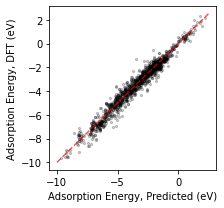

In [59]:
from sklearn.metrics import r2_score
print('number of data points:', len(df))
print('MAE:', np.mean(np.abs((yPredAll-Y_all_out))))
print('RMSE:', np.sqrt(np.mean((yPredAll-Y_all_out)**2)))
print('MAPE:', np.mean(np.abs((yPredAll-Y_all_out)/yPredAll)))
print('Max E:', np.max(np.abs((yPredAll-Y_all_out))))
print('Overall R^2:', r2_score(Y_all_out,yPredAll))

plt.figure(figsize=(3.2,3))
plt.scatter(yPredAll,Y_all_out,color='black',alpha=0.2,s=5)
plt.xlabel('Adsorption Energy, Predicted (eV)')
plt.ylabel('Adsorption Energy, DFT (eV)')
plt.plot([-10,2.5],[-10,2.5],color='red',linestyle='--',alpha=0.66)
plt.tight_layout()
plt.savefig('NewParityPlotLinearDirectFit.png',dpi=350)
plt.show()




In [60]:
df_all_out = copy.deepcopy(X_all_out)
df_all_out['adsorption_energy'] = Y_all_out
df_all_out['pred_adsorption_energy'] = yPredAll 

In [61]:
### Pass through useful info from df.

df_all_out['host_binding_elements'] = df.loc[X_all_out.index]['host_binding_elements']

In [62]:
pred = df_all_out['pred_adsorption_energy']
actual = df_all_out['adsorption_energy']
np.mean(np.abs((pred-actual)))

0.28533182582144834

Make a learning curve (not necessary most of the time)

In [110]:
def error_with_data(df, trainFracList, numRepeat = 2):
    maxIter = 2000
    
    #create interval start from .1 to 1.1 
#     intervals = np.arange(0.4, 1.1,frac)
    maes = []
    rmses = []
    maesstd = []
    rmsesstd = []
    sample_size = []

        #increasing data size
    for trainFrac in trainFracList:
        rmseInner = []
        maeInner = []
        for i in range(numRepeat):
            part_df = df.sample(frac=1)
            df_train=part_df.sample(frac=trainFrac)
            df_test=part_df.drop(df_train.index)
            guestParams = 0.55*np.ones(numFeatures*numGuestTypes)
            minResult = minimize(costFunction,guestParams,args = (df_train, linearModel),
                           method="COBYLA",options={'maxiter':maxIter}) 
            guestParamsFinal = minResult.x
            model1,X_test,Y_test = fitModel(df_test,guestParamsFinal, linearModel, returnObject = 'model+data')
            model,X_train,Y_train = fitModel(df_train,guestParamsFinal, linearModel, returnObject = 'model+data')
            yPred = model.predict(X_test)
            rmse = np.sqrt(np.mean((yPred-Y_test)**2))
            mae = np.mean(np.abs((yPred-Y_test)))
            rmseInner.append(rmse)
            maeInner.append(mae)

#             sample_size.append(len(part_df))

        maes.append(np.mean(maeInner))
        rmses.append(np.mean(rmseInner))
        maesstd.append(np.std(maeInner))
        rmsesstd.append(np.std(rmseInner))
        sample_size.append(len(df_train))

    return sample_size, rmses, maes, rmsesstd, maesstd
#     axes = plt.gca()
#     axes.set_xlim([xmin,xmax])
#     axes.set_ylim([0,2])

In [111]:
# sample_size, rmses, maes, rmsesstd, maesstd = error_with_data(df,[0.05,0.1,0.15,0.2,0.4,0.6,0.8,0.9], numRepeat = 5)
sample_size, rmses, maes, rmsesstd, maesstd = error_with_data(df,[0.01,0.05,0.1,0.2,0.6,0.9], numRepeat = 5)


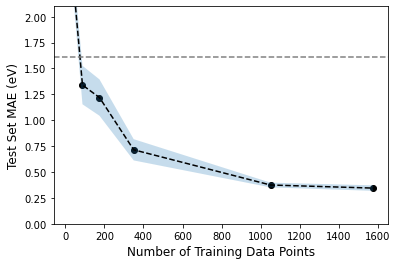

In [125]:
conv = 1
startPlot = 0
meanModelMAE = 1.614
plt.plot(sample_size[startPlot:],np.array(maes[startPlot:])*conv,c='black',linestyle='--')
ax = plt.gca()
# ax.set_yscale('log')
plt.scatter(sample_size[startPlot:],np.array(maes[startPlot:])*conv,c='black')
plt.xlabel('Number of Training Data Points',fontsize=12)
plt.ylabel('Test Set MAE (eV)',fontsize=12)
plt.ylim(0,2.1)
# plt.xlim(0,None)
plt.fill_between(sample_size[startPlot:], np.array(maes)[startPlot:] - np.array(maesstd)[startPlot:],
                         np.array(maes)[startPlot:] + np.array(maesstd)[startPlot:], alpha=0.25)

ax.axhline(meanModelMAE,linestyle = '--',color='gray')
# plt.text(x=900,y=meanModelMAE+0.1,s='Mean Model MAE',color='gray',fontsize=12)
plt.savefig('TMAdsEnLearnBiggerData_Alt.png',dpi=350)
plt.show()

Find biggest errors

In [168]:
formulas = [atomsList[i].get_chemical_formula() for i in df_all_out.index]
df_all_out.loc[:,'formulas'] = formulas
df_all_out['error']= df_all_out['pred_adsorption_energy'] - df_all_out['adsorption_energy']
df_all_out['abs_error']= np.abs(df_all_out['pred_adsorption_energy'] - df_all_out['adsorption_energy'])

df_all_out.sort_values(by='abs_error',ascending=False)[['formulas','adsorption_energy','pred_adsorption_energy','error','host_binding_elements']].head(30)

,formulas,adsorption_energy,pred_adsorption_energy,error,host_binding_elements
1446,CHAg36,-1.338756,-3.442319,-2.103564,[Ag]
1745,HORe29V7,-6.977164,-5.234546,1.742618,[V]
526,CAg36,-3.582173,-5.299971,-1.717798,"[Ag, Ag, Ag]"
525,CAg36,-3.643782,-5.299971,-1.656189,"[Ag, Ag, Ag]"
1695,CH3Ag29W7,-3.998968,-2.501776,1.497192,[W]
1424,CH2Ag36,-0.541236,-1.986312,-1.445076,[Ag]
132,Ag36F,-3.928716,-2.542019,1.386697,"[Ag, Ag, Ag]"
524,CAg36,-3.446340,-4.786638,-1.340299,"[Ag, Ag]"
1742,HOTa4Zr32,-6.461294,-5.132156,1.329138,[Zr]
131,Ag36F,-3.832783,-2.601068,1.231715,"[Ag, Ag]"


In [169]:
atomsTemp = atomsList[1426]
atomsTemp.wrap(center=(0.3,0.3,0.8))
# view(atomsTemp)

Look at individual adsorbates

In [170]:
from sklearn.metrics import r2_score
for column in df_all_out.columns:
    if 'guestConstant' in column:
        if column == 'guestConstant_CO_top': continue
        df_sub_out = df_all_out[df_all_out[column] != 0.0]
        print(column)
        pred = df_sub_out['pred_adsorption_energy']
        actual = df_sub_out['adsorption_energy']
        print('n: {}'.format(len(actual)))
        print('MAE: {:.3}'.format(np.mean(np.abs((pred-actual)))))
        print('RMSE: {:.3}'.format(np.sqrt(np.mean((pred-actual)**2))))
        print('MAPE: {:.3}'.format(np.mean(np.abs((pred-actual)/pred))))
        print('R^2:{:.3}'.format(r2_score(actual,pred)))

#         print(X_sub_out)

guestConstant_H_top
n: 58
MAE: 0.174
RMSE: 0.222
MAPE: 0.0868
R^2:0.619
guestConstant_H_bridge
n: 24
MAE: 0.18
RMSE: 0.224
MAPE: 0.0772
R^2:0.515
guestConstant_H_fcc_hollow
n: 49
MAE: 0.242
RMSE: 0.298
MAPE: 0.0958
R^2:0.466
guestConstant_F_top
n: 34
MAE: 0.293
RMSE: 0.357
MAPE: 0.0886
R^2:0.904
guestConstant_F_bridge
n: 15
MAE: 0.344
RMSE: 0.476
MAPE: 0.102
R^2:0.813
guestConstant_F_fcc_hollow
n: 44
MAE: 0.358
RMSE: 0.463
MAPE: 0.0978
R^2:0.889
guestConstant_K_top
n: 14
MAE: 0.147
RMSE: 0.196
MAPE: 0.0739
R^2:0.522
guestConstant_K_fcc_hollow
n: 14
MAE: 0.169
RMSE: 0.211
MAPE: 0.0783
R^2:0.444
guestConstant_N_bridge
n: 20
MAE: 0.225
RMSE: 0.296
MAPE: 0.0606
R^2:0.974
guestConstant_N_fcc_hollow
n: 50
MAE: 0.34
RMSE: 0.426
MAPE: 0.0784
R^2:0.944
guestConstant_NH2_top
n: 45
MAE: 0.169
RMSE: 0.201
MAPE: 0.0876
R^2:0.934
guestConstant_NH2_fcc_hollow
n: 8
MAE: 0.0791
RMSE: 0.101
MAPE: 0.0263
R^2:0.976
guestConstant_S_bridge
n: 20
MAE: 0.132
RMSE: 0.151
MAPE: 0.0291
R^2:0.982
guestConstant_S_

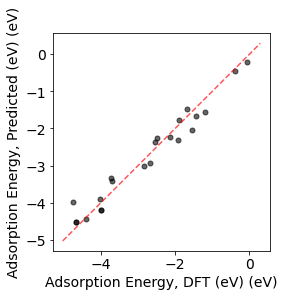

R^2:0.957


In [72]:
import matplotlib
matplotlib.rcParams.update({'font.size': 14})
colName ='guestConstant_OHTS_top' # 'guestConstant_CH4TS_top'
df_sub_out = df_all_out[df_all_out[colName] != 0.0]
pred = df_sub_out['pred_adsorption_energy']
actual = df_sub_out['adsorption_energy']

plt.scatter(actual,pred,color='black',alpha=0.6, s=25)
plt.xlabel('Adsorption Energy, DFT (eV) (eV)')
plt.ylabel('Adsorption Energy, Predicted (eV) (eV)')
ax = plt.gca()
ax.set_aspect(1)
plt.plot([np.min(pred)-0.5,np.max(pred)+0.5],[np.min(pred)-0.5,np.max(pred)+0.5],color='red',linestyle='--',alpha=0.66)
plt.savefig('OHTS.pdf')
plt.show()

print('R^2:{:.3}'.format(r2_score(actual,pred)))

In [147]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degree = 2
polyreg=make_pipeline(PolynomialFeatures(degree),LinearRegression())
polyreg.fit(pred.values.reshape(-1, 1),actual.values)
newPred = polyreg.predict(pred.values.reshape(-1, 1))
print(polyreg.named_steps['linearregression'].coef_,polyreg.named_steps['linearregression'].intercept_)
print(polyreg.predict([[-5],[-4]]))

[ 0.          0.1293443  -0.11982981] -1.4019039375192897
[-5.04437071 -3.83655811]


In [148]:
### Temp

# -5*9.21688527+(-5)**2*0.80160685 + 20.76368839319711

def correctCHTS(energy):
    return energy*9.21688527+(energy)**2*0.80160685 + 20.76368839319711

correctCHTS(-4)

-3.278143086802892

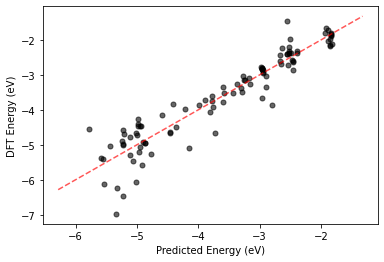

MAE: 0.309
RMSE: 0.438
R^2:0.882


In [149]:
plt.scatter(newPred,actual,color='black',alpha=0.6, s=25)
plt.xlabel('Predicted Energy (eV)')
plt.ylabel('DFT Energy (eV)')
plt.plot([np.min(newPred)-0.5,np.max(newPred)+0.5],[np.min(newPred)-0.5,np.max(newPred)+0.5],color='red',linestyle='--',alpha=0.66)
plt.show()

print('MAE: {:.3}'.format(np.mean(np.abs((newPred-actual)))))
print('RMSE: {:.3}'.format(np.sqrt(np.mean((newPred-actual)**2))))
print('R^2:{:.3}'.format(r2_score(actual,newPred)))

In [155]:
formulas = [atomsList[i].get_chemical_formula() for i in df_sub_out.index]
df_sub_out.loc[:,'formulas'] = formulas
df_sub_out[['formulas','adsorption_energy','pred_adsorption_energy','error','host_binding_elements']].tail(50)

/opt/anaconda3/lib/python3.7/site-packages/pandas/core/indexing.py:1745: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(ilocs[0], value)


,formulas,adsorption_energy,pred_adsorption_energy,error,host_binding_elements
1246,HCu33OTi3,-3.340037,-3.041554,0.298484,[Cu]
1247,HCu33OTi3,-4.644425,-4.538881,0.105544,[Ti]
1248,HCu33OTi3,-3.025082,-3.041554,-0.016472,[Cu]
1249,HOOs33Ti3,-4.150423,-4.653695,-0.503273,[Ti]
1250,HOOs33Ti3,-3.376647,-3.484027,-0.107380,[Os]
1251,HOPt33Ti3,-3.826072,-4.498039,-0.671968,[Ti]
1252,HOPt33Ti3,-2.677473,-2.728339,-0.050866,[Pt]
1254,HOPd27Ti9,-5.069929,-4.929346,0.140583,[Ti]
1256,HOZr36,-4.657288,-4.983414,-0.326126,[Zr]
1715,HCo4Ni32O,-2.824198,-3.114299,-0.290101,[Ni]


In [151]:
df_all_out.columns

Index(['sd_coupling_Ag', 'd_filling_n_Ag', 'e_conductivity_n_Ag',
       'd_filling_mult_Ag', 'constant_Ag', 'sd_coupling_Au', 'd_filling_n_Au',
       'e_conductivity_n_Au', 'd_filling_mult_Au', 'constant_Au',
       ...
       'guestConstant_CHTS_top', 'guestConstant_OHTS_top',
       'guestConstant_H2OTS_top', 'guestConstant_COTS_top',
       'adsorption_energy', 'pred_adsorption_energy', 'host_binding_elements',
       'formulas', 'error', 'abs_error'],
      dtype='object', length=174)

In [152]:
df_all_out.loc[1368].values #1398

array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4385958356163794, 0.0, 0.0,
       0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.7064018499999953, 0.8765422706167842,
       

In [153]:
# df_all_out[df_all_out['formulas'].str.contains("CH3")][['formulas','error','adsorption_energy','pred_adsorption_energy']]
#,'sd_coupling_V','d_filling_n_V'
cols = ['formulas','adsorption_energy','pred_adsorption_energy','error','host_binding_elements']
df_all_out[df_all_out['formulas'].str.contains("Ag35OTi")].sort_values(by='adsorption_energy',ascending=True).head(30)[cols]

,formulas,adsorption_energy,pred_adsorption_energy,error,host_binding_elements
1476,HAg35OTi,-4.027679,-3.966160,0.061519,[Ti]
1498,H2Ag35OTi,-0.533735,-0.471605,0.062130,[Ti]
1520,CAg35OTi,0.570471,-0.045549,-0.616020,[Ti]


In [123]:
### Temp

# 0.491763/2.078644191955706, -0.349722/0.5828696556886718

In [140]:
hostCoefs

array([-2.40520501e+00,  1.55664812e+00,  3.26717112e-01, -4.07037363e+00,
       -1.42519817e-01, -3.57912248e+00,  6.63516162e+00,  7.17257072e-02,
       -1.13670377e+01, -2.99000165e-02,  2.74277056e-01, -1.87166585e+00,
        2.25958683e-01, -9.23485814e-01, -2.12131976e+00,  2.89899167e+00,
       -1.40730960e+00,  3.39391208e-01, -1.30762621e-01, -3.74085758e+00,
       -1.88551586e-01,  3.53060366e+00, -3.26777965e-02, -8.75238704e+00,
       -1.24240970e+00,  2.63902431e+00,  1.00982455e+00,  2.32969189e-01,
       -2.34004683e+00, -2.80651944e+00,  4.90722376e+00,  4.22485353e-01,
        2.39765683e-01,  1.15296651e+00, -4.10738466e+00, -1.34836641e+00,
        3.17234647e+00, -6.39272455e-01, -4.92417048e+00, -1.63870888e+00,
        1.99307170e+00, -8.15582358e-01,  1.26763381e-02, -5.90218322e-01,
       -3.12076964e+00,  2.47078737e+00, -5.65294427e-01, -1.66359766e+00,
       -1.74323780e-01, -3.30283284e+00,  2.20070930e+00,  7.80353178e-01,
       -5.11258078e+00, -

Export models (guest models and host models)

In [141]:
exportDirectory = 'JSONFiles_WithTSs_AllData'

import json
import os

featureDict = []

uniqueElements = []
for colName in columns.values:
    if 'guestConstant' in colName: continue
    split = colName.split('_')
    hostElement = split[-1]
    uniqueElements.append(hostElement)
uniqueElements = np.unique(uniqueElements)
#     featureName = '_'.join(split[0:-1])


for whichElement in uniqueElements:
    tempDict = {}
    for coef,colName in zip(hostCoefs,columns.values):
        if 'guestConstant' in colName: continue
        split = colName.split('_')
        hostElement = split[-1]
        if whichElement !=hostElement: continue
        featureName = '_'.join(split[0:-1])
#         print(colName)
        fileName = 'hostParams_'+hostElement+'.txt'
        tempDict[featureName]=coef
        json_txt = json.dumps(tempDict, indent=4)
        with open(os.path.join(exportDirectory,fileName), 'w') as file:
            file.write(json_txt)
    
#     split = colName.split('_')
#     hostElement = split[-1]
#     featureName = '_'.join(split[0:-1])
# hostElement, featureName

In [142]:
### Order of coefficients: 'sd_coupling_Ag', 'd_filling_n_Ag', 'e_conductivity_n_Ag', 'd_filling_mult_Ag'

interceptsDict = {}
for coef,colName in zip(hostCoefs,columns.values):
    if 'guestConstant' in colName:
#     intercepts.append(coef)
        split = colName.split('_')
        guest = split[1]
        site = ('_').join(split[2:])
        interceptsDict[(guest,site)] = coef

guestParamsList = np.reshape(guestParamsLinear,[numGuestTypes,numFeatures])
for gp, guest, site in zip(guestParamsList, guestList, siteList):
#     print(gp,guest,site)
#     site = site.replace('fcc_hollow','hollow')
    fileName = os.path.join(exportDirectory,'guestParams__'+guest+'__'+site)
    tempDict = {}
    tempDict['coefficients'] = list(gp)
    tempDict['intercept'] = interceptsDict[(guest,site)]
    json_txt = json.dumps(tempDict, indent=4)
    with open(fileName, 'w') as file:
        file.write(json_txt)


In [143]:
guestParamsLinear

array([ 1.70016483,  1.56373757,  0.1499294 ,  0.93254755,  1.3954478 ,
        0.60567569,  2.38106777,  0.95202397,  1.33871332,  2.33152283,
        1.93343323,  1.71602276,  0.15688566,  0.65306343,  1.14920295,
        0.80908628,  0.08561186, -0.82004771,  6.07124772,  1.13570976,
       -0.11394919, -1.91609947,  5.49344608,  0.43501308,  1.91096589,
        2.4808635 ,  1.1877158 ,  2.28734545,  1.92351795, -0.2710452 ,
        0.79670385,  0.17025391, -0.34145904,  5.58523555,  2.96898494,
        1.03054109, -0.344427  ,  4.48747879,  4.95020295,  1.23773628,
        0.83731457,  1.28527931,  0.01231484,  0.76809971,  0.76756181,
       -0.84090895, -1.35054081,  1.12528569,  0.45871861,  2.69613259,
        4.82650424,  0.8056783 ,  0.64542432,  3.01631765,  6.00080227,
        1.03545197,  1.19871278,  0.66914498,  5.55401256,  1.02646298,
        0.90067513,  2.46652007,  7.63088849,  0.59853727,  1.34630689,
        2.7804812 , -1.56225917, -0.40911848,  0.57021959,  4.76

In [128]:
# i = 531 #525
# print(df_train.loc[i])
# print(df_train.loc[i][['sd_coupling_Ag','d_filling_n_Ag','e_conductivity_n_Ag',
#        'd_filling_mult_Ag', 'constant_Ag']])
# print(modelTrain.predict([X_train_out.loc[i]]))

## Do a quadratic fit on predicted energies for CH, by reading in params

In [182]:
### Try to read in guest params. This will probably only work if everything's in the same order.

importDirectory = 'JSONFiles_WithTSs_AllData_version3'

guestParamsReadList = []
for gp, guest, site in zip(guestParamsList, guestList, siteList):
#     print(gp,guest,site)
#     site = site.replace('fcc_hollow','hollow')
    fileName = os.path.join(importDirectory,'guestParams__'+guest+'__'+site)
#     tempDict = {}
#     tempDict['coefficients'] = list(gp)
#     tempDict['intercept'] = interceptsDict[(guest,site)]
#     json_txt = json.dumps(tempDict, indent=4)
    with open(fileName, 'r') as file:
        tempDict = json.load(file)
    guestParamsReadList.extend(tempDict['coefficients'])
#     guestParamsReadList.append(tempDict['intercept'])


In [183]:
np.array(guestParamsReadList)

array([ 2.17497188e+00,  4.90636946e-01, -1.33150734e-01,  8.28634156e-01,
        1.73771283e+00, -6.12883230e-02,  1.93746499e+00, -8.02395618e-02,
        1.66725244e+00,  1.60540343e-02,  1.09525582e+00, -1.83719589e-01,
        6.68292117e-02,  4.88827698e-01,  2.01724262e+00,  9.82141070e-01,
       -8.69508984e-02, -6.33010845e-01,  5.04079926e+00,  3.28538027e-01,
       -3.45911399e-01,  2.60686668e-01,  4.06618395e+00,  1.34581339e+00,
        2.52036389e+00,  2.51196645e-01,  1.96694959e-01,  4.44687904e-01,
        2.53777825e+00,  9.19766515e-01,  7.75329957e-01,  1.75181996e+00,
       -7.45330731e-01,  2.64578113e+00,  9.59195485e-01,  6.40335724e-01,
       -7.90643092e-01,  2.40034668e+00,  1.37569524e+00,  7.66819365e-01,
        9.00481780e-01,  8.11881023e-01, -6.10799410e-01,  1.40009859e+00,
        9.16733363e-01,  1.67098911e+00, -1.29603405e+00,  8.62389262e-01,
        3.74198028e-01,  1.20111672e+00,  2.86324788e+00, -2.32437403e-01,
        6.17842786e-01,  

In [184]:
modelAll,X_all_out,Y_all_out = fitModel(df, guestParamsReadList, linearModel, returnObject = 'model+data')
yPredAll = modelAll.predict(X_all_out)

number of data points: 1750
MAE: 0.23916768050859413
RMSE: 0.33974784402509484
MAPE: 0.12485995575070509
Max E: 2.087235820197423
Overall R^2: 0.9723048721283064


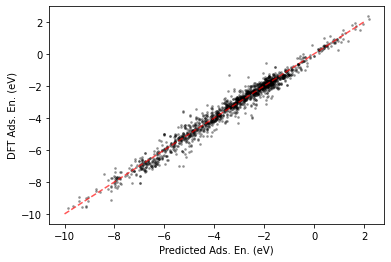

In [186]:
from sklearn.metrics import r2_score
print('number of data points:', len(df))
print('MAE:', np.mean(np.abs((yPredAll-Y_all_out))))
print('RMSE:', np.sqrt(np.mean((yPredAll-Y_all_out)**2)))
print('MAPE:', np.mean(np.abs((yPredAll-Y_all_out)/yPredAll)))
print('Max E:', np.max(np.abs((yPredAll-Y_all_out))))
print('Overall R^2:', r2_score(Y_all_out,yPredAll))


plt.scatter(yPredAll,Y_all_out,color='black',alpha=0.3,s=3)
plt.xlabel('Predicted Ads. En. (eV)')
plt.ylabel('DFT Ads. En. (eV)')
plt.plot([-10,2],[-10,2],color='red',linestyle='--',alpha=0.66)
plt.show()




In [190]:
df_all_out = copy.deepcopy(X_all_out)
df_all_out['adsorption_energy'] = Y_all_out
df_all_out['pred_adsorption_energy'] = yPredAll 

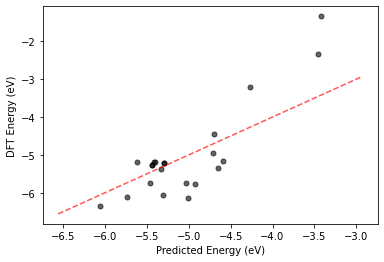

R^2:0.641


In [194]:
colName ='guestConstant_CHTS_top' # 'guestConstant_CH4TS_top'
df_sub_out = df_all_out[df_all_out[colName] != 0.0]
pred = df_sub_out['pred_adsorption_energy']
actual = df_sub_out['adsorption_energy']

plt.scatter(pred,actual,color='black',alpha=0.6, s=25)
plt.xlabel('Predicted Energy (eV)')
plt.ylabel('DFT Energy (eV)')
plt.plot([np.min(pred)-0.5,np.max(pred)+0.5],[np.min(pred)-0.5,np.max(pred)+0.5],color='red',linestyle='--',alpha=0.66)
plt.show()

print('R^2:{:.3}'.format(r2_score(actual,pred)))

In [195]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degree = 2
polyreg=make_pipeline(PolynomialFeatures(degree),LinearRegression())
polyreg.fit(pred.values.reshape(-1, 1),actual.values)
newPred = polyreg.predict(pred.values.reshape(-1, 1))
print(polyreg.named_steps['linearregression'].coef_,polyreg.named_steps['linearregression'].intercept_)
print(polyreg.predict([[-5],[-4]]))

[0.         7.92503657 0.67539079] 17.461287800818912
[-5.27912527 -3.43260582]


In [197]:
### Temp

# -5*9.21688527+(-5)**2*0.80160685 + 20.76368839319711

def correctCHTS(energy):
    return energy*7.92503657+(energy)**2*0.67539079 + 17.461287800818912

correctCHTS(-5)

-5.279125299181089

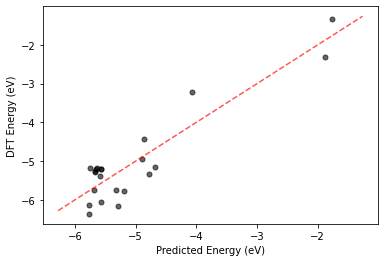

MAE: 0.446
RMSE: 0.484
R^2:0.838


In [198]:
plt.scatter(newPred,actual,color='black',alpha=0.6, s=25)
plt.xlabel('Predicted Energy (eV)')
plt.ylabel('DFT Energy (eV)')
plt.plot([np.min(newPred)-0.5,np.max(newPred)+0.5],[np.min(newPred)-0.5,np.max(newPred)+0.5],color='red',linestyle='--',alpha=0.66)
plt.show()

print('MAE: {:.3}'.format(np.mean(np.abs((newPred-actual)))))
print('RMSE: {:.3}'.format(np.sqrt(np.mean((newPred-actual)**2))))
print('R^2:{:.3}'.format(r2_score(actual,newPred)))

### Train-test split, to gauge accuracy

In [249]:
df_train=df.sample(frac=0.90)
df_test=df.drop(df_train.index)
df_train

,directory,adsorption_energy,site_name,guest_name,host_binding_elements,host_binding_atoms,sd_coupling_all,d_filling_n_all,e_conductivity_n_all,d_filling_central_all,...,guestConstant_Methylidyne_top,guestConstant_Methylidyne_bridge,guestConstant_Methylidyne_hollow,guestConstant_O_top,guestConstant_O_bridge,guestConstant_O_fcc_hollow,guestConstant_Hydroxyl_top,guestConstant_Hydroxyl_bridge_0h,guestConstant_Hydroxyl_fcc_hollow,guestConstant_Methoxy_top
415,SPonShared/Done/OtherAds/SulfurHf/HHollow,-6.575006,fcc_hollow,S,"[Hf, Hf, Hf]","[0, 1, 2]","[0.2851890178923148, 0.28518959431589386, 0.28...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, ...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
354,SPonShared/Done/OxAds/NH2Pt3inRu/Top2_Constrain,-2.452783,top,NH2,[Ru],[4],"[0.29233729043165757, 0.292339198074009, 0.292...","[0.20000000000000007, 0.20000000000000007, 0.2...","[0.44, 0.44, 0.44, -0.14666666666666667, -0.14...","[0.9, 0.9, 0.9, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1239,SPonShared/Done/OxAds//OHRuonPd/Top-4,-3.478080,top,Hydroxyl,[Ru],[0],"[0.25732541336795967, 0.25732527644806935, 0.2...","[-0.0666666666666667, -0.0666666666666667, -0....","[-0.6, -0.6, -0.6, -0.6, -0.6, -0.6, -0.6, -0....","[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...",...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
531,SPonShared/Done/MethylAds//CarbonAu/HHollow,-4.424336,hollow,C,"[Au, Au, Au]","[1, 2, 0]","[0.20666510755265383, 0.2066663906322868, 0.20...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1040,SPonShared/Done/MethylAds//MethylidyneRu/FHollow,-6.647390,hollow,Methylidyne,"[Ru, Ru, Ru]","[2, 1, 3]","[0.2944429682464379, 0.29444394342841285, 0.29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...",...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,SPonShared/Done/OxAds//HydrogenPtonAg/Top,-2.551885,top,H,[Pt],[0],"[0.21088819371318474, 0.21088824030721193, 0.2...","[-0.033333333333333326, -0.033333333333333326,...","[-0.02, -0.02, -0.02, -0.02, -0.02, -0.02, -0....","[0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, ...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1133,SPonShared/Done/OxAds//OxygenTi3inPt/FHollow1,-5.957156,fcc_hollow,O,"[Ti, Pt, Pt]","[1, 3, 4]","[0.2612889484455054, 0.26129180985452405, 0.26...","[-0.6000000000000001, -0.6000000000000001, -0....","[-0.69, -0.69, -0.69, 0.22999999999999998, 0.2...","[0.3, 0.3, 0.3, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, ...",...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
97,SPonShared/Done/OxAds//HydrogenRh/Top,-2.458292,top,H,[Rh],[0],"[0.26759568247664817, 0.26759649203751723, 0.2...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, ...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
157,SPonShared/Done/OtherAds/FlorineCuonPd/Top,-3.897509,top,F,[Cu],[0],"[0.14772502391669007, 0.14772495481124867, 0.1...","[0.033333333333333326, 0.033333333333333326, 0...","[1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [224]:
import time
###Do a fit to training data.
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler

maxIter = 5000

linearModel = LinearRegression(fit_intercept=False)

# degree=1
# polyModel=make_pipeline(PolynomialFeatures(degree),linear_model.Ridge(alpha=10**-19))

guestParams = 0.55*np.ones(numFeatures*numGuestTypes) #Could make random?
# guestParams =  [2.57208698, 1.59202756, -0.15886274, 1.16739785, 1.99167281, 1.43697224, 0.35072093, 1.2737259,  2.27774505, 0.92168511, 2.24565961, 0.19796513, 0.47398603, 1.79567023, 1.79188655, 1.34460228, 0.41527175, -0.58263721, 2.5309821, -0.2240045, -0.22136789, 1.36988906, 1.3450375,  1.75778242, 2.41572842, 1.74420555, 1.10361684, 1.22092176, 2.22802556, 0.38135387, 2.59509214, 0.49999071, -0.42750825, 0.97911581, 0.41601176, 0.69253086, -0.29444642, 1.43914339, 2.0027649, -0.18499758, 1.44574003, 0.38481614, 0.97084219, 0.24201968, 0.83128513, -0.29858779, 1.02750653, 0.30680932, 0.3966735,  0.49699149, 1.10116587, 0.488302, 0.9522574,  0.99320056, 0.76836416, -0.01615832, 2.04812693, 1.15680935, 1.65359792, 0.30213625, 1.47730824, 1.32795693, 2.83178794, 0.05735609, 1.10439791, 1.80157718, -1.07107396, -0.16767599, 0.38891802, 3.06009231, -0.96774994, 0.88383137, 1.19254882, 1.93202232, -0.65568744, -0.14098858, 2.71927996, 1.76436271, 0.65758414, 1.17211737, 1.5973839, -0.26522981, -0.15161104, -0.02430579, 1.14992419, 0.73855015, 0.04904736, 1.51966362, 1.43488148, 0.91192686, 1.90936223, 0.37173398, 1.42547125, 1.21061543, 0.64386932, 0.34274691, 1.99450033, 0.67623447, 1.06901722, -0.34684271, 0.48915454, 1.35619684, 1.03230812, 0.41595444, 1.67095804, 1.18129972, -0.20900165, -0.28053707, 1.56361742, 1.7092231,  1.55310958, 0.0729563,  0.50581337, 1.29111342, 0.39388299, 0.18635561, 1.09292824, 1.83073349, 1.66326395, -0.16557604, 1.77881984, 2.06978723, 1.35985594, -0.5701428,  0.06024679, 2.68510862, -0.41912738, 1.19936341, -0.12245831, 1.12109686, 1.36516849, 1.01354856, -0.77937038, 1.49178938, 1.97954289, 0.36224413, 0.80145585, 0.396691, 0.39418091, 0.37772007, 0.29242041, -0.13320696, 2.0056207,  1.27968434, 0.00765508, 0.63670449, 1.92474609, 0.85594585, 0.87932652, 0.56651998, 0.37801437, 0.32110371]
#minimizer_kwargs = {"method": "COBYLA","options":{"maxiter":150}} #Could try: L-BFGS-B, BFGS, Powell, ’Nelder-Mead’, 'CG', or many others
start=time.time()
#minResult = basinhopping(costFunction, guestParams,niter=150,minimizer_kwargs=minimizer_kwargs,stepsize=0.4)
minResultLinearTrain = minimize(costFunction,guestParams,args = (df_train, linearModel),
                           method="COBYLA",options={'maxiter':maxIter}) 
end=time.time()
print('time:',end - start)

time: 964.7259361743927


In [225]:
guestParamsLinearTrain = minResultLinearTrain.x
minResultLinearTrain

     fun: 0.3342024549577862
   maxcv: 0.0
 message: 'Maximum number of function evaluations has been exceeded.'
    nfev: 5000
  status: 2
 success: False
       x: array([ 2.55016896,  1.46449823,  0.7323523 ,  0.51897032,  2.01368903,
        0.56855472,  1.21721193,  0.13506374,  1.85036098,  1.08666333,
        1.76962284,  0.34638446,  0.12094242,  3.02253158,  1.75163307,
        1.05006022,  0.15160465,  1.32652492,  1.64770992,  1.20478676,
       -0.22795335,  1.57929932,  2.51734912,  0.36221378,  2.8356245 ,
        1.46800169,  0.84215509,  0.63833715,  2.78966465,  2.11797012,
        1.92077785,  0.87706265, -0.51535988,  0.90013775, -0.28951922,
        1.61195257, -0.49281799,  0.50652065, -1.03064193,  1.35318954,
        1.27889422,  1.39865783,  0.81629703,  0.51812908,  0.5933355 ,
        1.58260049,  0.3354252 ,  0.77436886,  0.60624635,  0.57640571,
        0.56821695,  0.78854529,  0.93780873,  0.85595205, -0.24150991,
        1.20203315,  1.63427822,  3.196881

In [226]:
modelTrain,X_train_out,Y_train_out = fitModel(df_train, guestParamsLinearTrain, linearModel, returnObject = 'model+data')
yPredTrain = modelTrain.predict(X_train_out)
modelTest,X_test_out,Y_test_out = fitModel(df_test, guestParamsLinearTrain, linearModel, returnObject = 'model+data')
yPredTest = modelTrain.predict(X_test_out)


training data: 1189
training RMSE: 0.3342024549577862


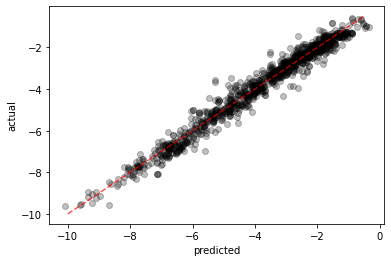

test RMSE: 0.4076244898891957


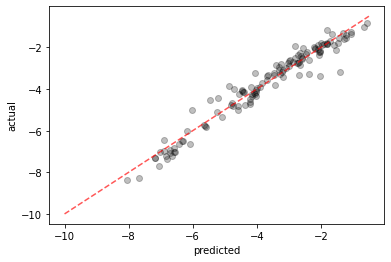

In [227]:
print('training data:', len(df_train))
# print('training MAE:', errorTrain)
print('training RMSE:', np.sqrt(np.mean((yPredTrain-Y_train_out)**2)))

plt.scatter(yPredTrain,Y_train_out,color='black',alpha=0.25)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.plot([-10,-0.5],[-10,-0.5],color='red',linestyle='--',alpha=0.66)
plt.show()



# print('test MAE:', errorTest)
print('test RMSE:', np.sqrt(np.mean((yPredTest-Y_test_out)**2)))

plt.scatter(yPredTest,Y_test_out,color='black',alpha=0.25)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.plot([-10,-0.5],[-10,-0.5],color='red',linestyle='--',alpha=0.66)
plt.show()



In [ ]:
### Below here can probably be deleted soon

In [69]:
### Manual test

### This is what SurfEP currently returns, but it's wrong:
-2.1912238778234947*0.17331987*1.9439715599048748 + 4564168364.490479 - 4564168365.3974

### Trying things

-2.1912238778234947*0.17331987*1.9439715599048748 - 0.5133834932781288 + 4564168364.490479 - 4564168365.3974

-2.158590316772461

In [95]:
modelTrain.coef_

4564168364.490479

In [96]:
1.9439715599048748*0.17331987+4564168364.490479-4564168365.3974

-0.5699911117553711

In [97]:
np.dot(X_train_out.loc[0],modelTrain.coef_)

-1.645207405090332

In [110]:
temp = modelTrain.predict([X_train_out.loc[0]])[0]

In [111]:
[ x - temp for x in yPredTrain if ( -1.66 < x < -1.6)]

[0.0,
 -0.0063838958740234375,
 0.04088401794433594,
 0.03597545623779297,
 0.04088401794433594,
 0.04088401794433594,
 0.018998146057128906,
 0.019008636474609375,
 -0.013674736022949219,
 0.041118621826171875,
 0.04454803466796875,
 0.04454803466796875,
 0.043468475341796875,
 0.0308074951171875,
 -0.010217666625976562,
 0.04154682159423828,
 0.022322654724121094,
 0.007447242736816406,
 0.031241416931152344,
 -0.013857841491699219]

In [55]:
columns

Index(['sd_coupling_Ag', 'd_filling_n_Ag', 'e_conductivity_n_Ag',
       'd_filling_mult_Ag', 'constant_Ag', 'sd_coupling_Au', 'd_filling_n_Au',
       'e_conductivity_n_Au', 'd_filling_mult_Au', 'constant_Au',
       ...
       'guestConstant_Methylidyne_top', 'guestConstant_Methylidyne_bridge',
       'guestConstant_Methylidyne_hollow', 'guestConstant_O_top',
       'guestConstant_O_bridge', 'guestConstant_O_fcc_hollow',
       'guestConstant_Hydroxyl_top', 'guestConstant_Hydroxyl_bridge_0h',
       'guestConstant_Hydroxyl_fcc_hollow', 'guestConstant_Methoxy_top'],
      dtype='object', length=128)

# For below here, should implement some error checking, train-test split, etc., and delete the rest.

In [ ]:
minResultLinear

In [ ]:
print(minResultLinear.x)
print(minResultLinear.fun)
# print(costFunction(minResult.x,df))

In [ ]:
guestParamsLinear = minResultLinear.x
len(guestParamsLinear)


In [ ]:
modelType = LinearRegression(fit_intercept=False)

# alpha = 0.1 #0.01 lowest test errors. Up to 0.5 gives similar results.
# degree=2
# modelType=make_pipeline(PolynomialFeatures(degree),linear_model.Ridge(alpha=alpha))

modelAllTrain,X_train,Y_train = fitModel(df_train,guestParamsLinear, modelType, returnObject = 'model+data')
modelAllTest,X_test,Y_test = fitModel(df_test,guestParamsLinear, modelType, returnObject = 'model+data')

# print(modelAllTrain.coef_[0:5])
# print(modelAllTest.coef_[0:5])

yPredTrain = modelAllTrain.predict(X_train)
errorTrain = np.mean(np.abs(yPredTrain-Y_train))

yPred = modelAllTrain.predict(X_test)
errorTest = np.mean(np.abs(yPred-Y_test))

print('training data:', len(df_train))
print('training MAE:', errorTrain)
print('training RMSE:', np.sqrt(np.mean((yPredTrain-Y_train)**2)))
print('test MAE:', errorTest)
print('test RMSE:', np.sqrt(np.mean((yPred-Y_test)**2)))

In [ ]:
### Current part I'm working on. May want to try fitting linear model first to get a good guess for guestParams, and then use that to seed the KRR stuff. (Or could try not reoptimizing guestParams after doing linear fit.)


# def gridSearch():
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import KFold
import itertools
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn import linear_model

maxIter = 500
gammas = [0.01]
alphas =  [0.05,0.1,0.25,0.5,0.75,1,2]
kernels = ['nothing']#['linear','rbf','laplacian','polynomial'] ## 'rbf'


d = []


for alpha, gamma, kernel in itertools.product(alphas,gammas,kernels):
#     modelType = KernelRidge(gamma=gamma,alpha=alpha,kernel=kernel,degree=2)
#     modelType = LinearRegression(fit_intercept=False)
    
    degree=2
    modelType=make_pipeline(PolynomialFeatures(degree),linear_model.Ridge(alpha=alpha))

    ## TODO: Split into k-folds
    kf = KFold(n_splits = 6, shuffle = True, random_state = 2)
#     result = next(kf.split(df_train), None)
    
#     foldsTrain = df_train.iloc[result[0]]
#     foldTest =  df_train.iloc[result[1]]

    innerTestRMSEs = []
    innerTrainRMSEs = []
    innerTestMAEs = []

    for foldsTrain,foldTest in kf.split(df_train):
#         print(test)
#         print(train)
        dfFoldTrain = df_train.iloc[foldsTrain]
        dfFoldTest = df_train.iloc[foldTest]
        
        guestParams = guestParamsLinear
        minResultTrain = minimize(costFunction,guestParams,args = (dfFoldTrain, modelType),
                                  method="COBYLA",options={'maxiter':maxIter})
        
        finalModel_test,X_test,Y_test = fitModel(dfFoldTest,minResultTrain.x,modelType, returnObject = 'model+data')

        finalModel,X_train,Y_train = fitModel(dfFoldTrain,minResultTrain.x,modelType, returnObject = 'model+data')

        yPredTrain = finalModel.predict(X_train)
        yPred = finalModel.predict(X_test)
        
        innerTestRMSEs.append(np.sqrt(np.mean((yPred-Y_test)**2)))
        innerTestMAEs.append(np.mean(np.abs((yPred-Y_test))))
        innerTrainRMSEs.append(np.sqrt(np.mean((yPredTrain-Y_train)**2)))
        
    print(innerTestRMSEs)


#         print(len(yPred))
#         print('Test RMSE: {:.3f}'.format(np.sqrt(np.mean((yPred-Y_test)**2))))
#         print('Test MAE: {:.3f}'.format(np.mean(np.abs(yPred-Y_test))))
#         print('Train RMSE: {:.3f}'.format(np.sqrt(np.mean((yPredTrain-Y_train)**2))))
    d.append({'alpha':alpha,'gamma':gamma,'kernel':kernel,
             'testRMSE':np.mean(innerTestRMSEs), 'trainRMSE':np.mean(innerTrainRMSEs),
             'testMAE':np.mean(innerTestMAEs)})
    print(alpha,gamma,kernel,np.mean(innerTestRMSEs),np.mean(innerTrainRMSEs),np.mean(innerTestMAEs))
    
cvDF=pd.DataFrame(d)


In [ ]:
cvDF

In [ ]:
cvDF ## Currently, without further optimization of guestParams

In [ ]:
cvDF

In [ ]:
maxIter = 1

alpha = 0.5 #0.01 lowest test errors. Up to 0.5 gives similar results.
degree=2
modelType=make_pipeline(PolynomialFeatures(degree),linear_model.Ridge(alpha=alpha))

guestParams = guestParamsLinear
minResultTrainAgain = minimize(costFunction,guestParams,args = (df_train, modelType),
                          method="COBYLA",options={'maxiter':maxIter})

finalModel_test,X_test,Y_test = fitModel(df_test,minResultTrainAgain.x,modelType, returnObject = 'model+data')

finalModel,X_train,Y_train = fitModel(df_train,minResultTrainAgain.x,modelType, returnObject = 'model+data')

yPredTrain = finalModel.predict(X_train)
yPred = finalModel.predict(X_test)

errorTrain = np.mean(np.abs(yPredTrain-Y_train))
errorTest = np.mean(np.abs(yPred-Y_test))

print('Not re-optimizing guest parameters')
print('training data:', len(df_train))
print('training MAE:', errorTrain)
print('training RMSE:', np.sqrt(np.mean((yPredTrain-Y_train)**2)))
print('test MAE:', errorTest)
print('test RMSE:', np.sqrt(np.mean((yPred-Y_test)**2)))

maxIter = 2000

alpha = 0.1 #0.01 lowest test errors. Up to 0.5 gives similar results.
degree=2
modelType=make_pipeline(PolynomialFeatures(degree),linear_model.Ridge(alpha=alpha))

guestParams = guestParamsLinear
minResultTrainAgain = minimize(costFunction,guestParams,args = (df_train, modelType),
                          method="COBYLA",options={'maxiter':maxIter})

finalModel_test,X_test,Y_test = fitModel(df_test,minResultTrainAgain.x,modelType, returnObject = 'model+data')

finalModel,X_train,Y_train = fitModel(df_train,minResultTrainAgain.x,modelType, returnObject = 'model+data')

yPredTrain = finalModel.predict(X_train)
yPred = finalModel.predict(X_test)

errorTrain = np.mean(np.abs(yPredTrain-Y_train))
errorTest = np.mean(np.abs(yPred-Y_test))

print('Re-optimizing guest parameters')
print('training data:', len(df_train))
print('training MAE:', errorTrain)
print('training RMSE:', np.sqrt(np.mean((yPredTrain-Y_train)**2)))
print('test MAE:', errorTest)
print('test RMSE:', np.sqrt(np.mean((yPred-Y_test)**2)))

In [ ]:
minResultTrain.x

In [ ]:
# def randomSearch(Df,guestParams):
#     from sklearn.model_selection import RandomizedSearchCV
#     from sklearn.kernel_ridge import KernelRidge
#     guestParams = np.append(np.reshape(guestParams,[numGuestTypes,numFeatures]),[[1] for i in range(numGuestTypes)],axis=1)
#     # whichGuest = 0
#     xDFList = []
#     yDFList = []
#     #     print(allFeatureList)
#     for whichGuest,(guest,site) in enumerate(zip(guestList,siteList)):
#         dfSubset = Df.loc[(Df['guest_name'] == guest) & (Df['site_name'] == site)]
#     #         print(dfSubset[allFeatureList].shape[1])
#         guestParamsMult1=np.tile(guestParams[whichGuest],int((dfSubset[allFeatureList].shape[1]-numGuestTypes)/len(guestParams[whichGuest])))
#     #         print(guestParamsMult1.shape)
#         guestParamsMult = np.concatenate((guestParamsMult1,np.ones(numGuestTypes)))
#     #         print(guestParamsMult.shape)
#         XRawGuest = dfSubset[allFeatureList]
#         XGuest = XRawGuest * guestParamsMult
#         YGuest = dfSubset['adsorption_energy']
#         xDFList.append(XGuest)
#         yDFList.append(YGuest)
#     X = pd.concat(xDFList)
#     Y = pd.concat(yDFList)

#     alpha = [10**i for i in range(-6,5)]
#     gamma = [10**i for i in range(-6,5)]
#     #kernel = ['rbf','laplacian']
#     param_dist = dict(alpha=alpha,gamma = gamma)
#     kr = KernelRidge(kernel='rbf')
#     rand = RandomizedSearchCV(kr, param_dist, cv=10, n_iter=30, random_state=4)
#     rand.fit(X=X,y=Y)
#     print(rand.best_params_)
#     return rand.best_estimator_




In [ ]:
# guestParams = 0.5*np.ones(numFeatures*numGuestTypes)
# krr=randomSearch(df_train,guestParams)

In [ ]:
def randomSearch2(Df,guestParams):
    from sklearn.model_selection import RandomizedSearchCV
    from sklearn.kernel_ridge import KernelRidge
    targetName = 'adsorption_energy'
    guestParams = np.append(np.reshape(guestParams,[numGuestTypes,numFeatures]),[[1] for i in range(numGuestTypes)],axis=1)
    # whichGuest = 0
    xDFList = []
    yDFList = []
#     print(allFeatureList)
    for whichGuest,(guest,site) in enumerate(zip(guestList,siteList)):
        dfSubset = Df.loc[(Df['guest_name'] == guest) & (Df['site_name'] == site)]
#         print(dfSubset[allFeatureList].shape[1])
        guestParamsMult1=np.tile(guestParams[whichGuest],int((dfSubset[allFeatureList].shape[1]-numGuestTypes)/len(guestParams[whichGuest])))
#         print(guestParamsMult1.shape)
        guestParamsMult = np.concatenate((guestParamsMult1,np.ones(numGuestTypes)))
#         print(guestParamsMult.shape)
        XRawGuest = dfSubset[allFeatureList]
        XGuest = XRawGuest * guestParamsMult
        YGuest = dfSubset[targetName]
        xDFList.append(XGuest)
        yDFList.append(YGuest)
    X = pd.concat(xDFList)
    Y = pd.concat(yDFList)

#     alpha = [10**i for i in range(-6,3)]
#     gamma = [10**i for i in range(-6,2)]
    alpha = np.logspace(-2,1,150)
    gamma = np.logspace(-6,-3,150)
    #kernel = ['rbf',']
    param_dist = dict(alpha=alpha,gamma = gamma)
    kr = KernelRidge(kernel='rbf')
    rand = RandomizedSearchCV(kr, param_dist, cv=8, n_iter=200, random_state=4, verbose = 2, n_jobs = -1) #scoring = 'neg_root_mean_squared_error',
    rand.fit(X=X,y=Y)
    print(rand.best_params_)
#     print(rand.cv_results_)
    return rand.best_estimator_, rand.cv_results_

In [ ]:
### Hyperparameter tuning

guestParams = 0.55*np.ones(numFeatures*numGuestTypes)
krr, cvResults = randomSearch2(df_train,guestParams)


In [ ]:
dfCV = pd.DataFrame(cvResults)[['param_gamma','param_alpha','mean_test_score','std_test_score','rank_test_score']]
# display(dfCV.sort_values(by=['rank_test_score']).head(20))

### Take highest alpha within one std of best model
cutoff = dfCV.sort_values(by=['rank_test_score']).iloc[0]['mean_test_score'] - dfCV.sort_values(by=['rank_test_score']).iloc[0]['std_test_score']
selectModelsDF = dfCV.query('mean_test_score>@cutoff')
maxAlphaRow = selectModelsDF.loc[selectModelsDF['param_alpha'].index[np.argmax(np.array(selectModelsDF['param_alpha']))]]
display(maxAlphaRow)

In [ ]:
### Choose model, either by hand or by taking from CV (perhaps using one-standard-error rule: use simplest model within one standard error of best model)
from sklearn.kernel_ridge import KernelRidge


# modelType = KernelRidge(gamma=maxAlphaRow['param_gamma'], alpha=maxAlphaRow['param_alpha'], kernel = 'rbf')
modelType = KernelRidge(gamma=0.001,alpha=1.0e-01,kernel='rbf') #gamma=0.00005,alpha=1.25

print(modelType)

In [ ]:
# def fitModel(Df, guestParams, modelType, returnObject = 'model+data'):
#     from sklearn.kernel_ridge import KernelRidge
#     targetName = 'adsorption_energy'
#     guestParams = np.append(np.reshape(guestParams,[numGuestTypes,numFeatures]),[[1] for i in range(numGuestTypes)],axis=1)
#     # whichGuest = 0
#     xDFList = []
#     yDFList = []
# #     print(allFeatureList)
#     for whichGuest,(guest,site) in enumerate(zip(guestList,siteList)):
#         dfSubset = Df.loc[(Df['guest_name'] == guest) & (Df['site_name'] == site)]
# #         print(dfSubset[allFeatureList].shape[1])
#         guestParamsMult1=np.tile(guestParams[whichGuest],int((dfSubset[allFeatureList].shape[1]-numGuestTypes)/len(guestParams[whichGuest])))
# #         print(guestParamsMult1.shape)
#         guestParamsMult = np.concatenate((guestParamsMult1,np.ones(numGuestTypes)))
# #         print(guestParamsMult.shape)
#         XRawGuest = dfSubset[allFeatureList]
#         XGuest = XRawGuest * guestParamsMult
#         YGuest = dfSubset[targetName]
#         xDFList.append(XGuest)
#         yDFList.append(YGuest)
# #         print(XGuest.index)

#     X = pd.concat(xDFList)
#     Y = pd.concat(yDFList)
# #     print(X.index)
# #     print(Y.index)
    

#     model = modelType
#     model.fit(X=X,y=Y)
#     modelReturn = copy.deepcopy(model)

#     if returnObject == 'model+data':
#         return modelReturn,X,Y
#     elif returnObject == 'residuals':
#         allResiduals = model.predict(X) - Y
#         return allResiduals
    

# def costFunction(guestParams,*args): 
#     ### reshape in a nice way and add multiplier of 1 for constant columns:
#     Df, model = args
#     allResiduals = fitModel(Df,guestParams,model, returnObject = 'residuals')
#     return np.sqrt(np.mean(np.abs(allResiduals)**2))
# # print("MAE : ", np.mean(np.abs(allResiduals)))
# # print("Max error : ",np.max(np.abs(allResiduals)))


# # x_train,x_test,y_train,y_test = train_test_split(X,Y,random_state=randState, test_size=testSize)




In [ ]:
###Do the actual fit.

import time

guestParams = 0.1*np.ones(numFeatures*numGuestTypes) #Could make random?
start=time.time()
minResultTrain = minimize(costFunction,guestParams,args = (df_train, modelType),
                          method="COBYLA",options={'maxiter':1000}) #
# minResultTest = minimize(costFunction,guestParams,args = (df_test, modelType),method="COBYLA") 

end=time.time()
print('time:', end - start)

print(minResultTrain.x)
print('Train RMSE', minResultTrain.fun)
# print(costFunction(minResult.x,df_train,modelType))

In [ ]:
# import time
# ###Do the actual fit.

# ###TODO: Improve guess. Maybe repeat 4 guesses--looks like first is usually negative; 4th is usually pretty small.
# ###TODO: Try minimizing each adsorbate separately for improved guess?


# guestParams = 0.55*np.ones(numFeatures*numGuestTypes) #Could make random?
# #guestParams =[-5.77950233,  9.34762227, -2.16211068, -0.34761379, -4.81129211, -0.41912559,  1.80059628,  0.7125608, -4.45938515, -5.20492391,  6.93818963,  1.4170561, -1.01886858,  2.93056206,  4.76675433, -1.40660552,  0.12188285,  8.29579607, -7.00864374, -13.49292907,  0.78076014,  6.82713369, -4.32666333,  4.73496919, -7.34894624, -6.55276514,  0.33491076,  6.41676643, -7.22606618,  9.52266407, -4.86375654,  8.23658131, 15.74507552,  1.43590822, -3.07063777, -10.45419629,  2.42487503, -5.7094615,  14.84897465,  2.14150397, 14.71251565,  4.10906332,  2.44827301,  6.24945367, -0.40023923, -4.64206067, -0.27273465, -3.42681871, -1.74246133, -3.3303032, 12.89709092,  2.55508042, -0.99868697, -6.92882975, -9.31673273,  0.49627533, -8.49663707,  1.77540939, 14.08907837,  7.12249673, -0.91398835,  2.53594287, -1.4515273, 5.75714029,  3.22086303, -3.16689975, 16.34449455, -2.25520627,  1.13210959,  7.76678893, 20.05795116, -5.96314012,  3.23506733,  0.82035992, -2.87394499, -0.15185882,  2.43018149,  1.28511486,  5.13959818, -4.63063073, -4.11370311, -0.88655256, -12.83401185,  1.29640778,  3.10583034, -9.49795328, -3.04319874,  6.9699448 ]
# #minimizer_kwargs = {"method": "COBYLA","options":{"maxiter":150}} #Could try: L-BFGS-B, BFGS, Powell, ’Nelder-Mead’, 'CG', or many others
# start=time.time()
# #minResult = basinhopping(costFunction, guestParams,niter=150,minimizer_kwargs=minimizer_kwargs,stepsize=0.4)
# minResult = minimize(costFunction,guestParams,df_train,method="COBYLA") 
# end=time.time()
# print(end - start)

In [ ]:
print(costFunction(minResultTrain.x,df_train,modelType))
print(minResultTrain.x)

In [ ]:
###TODO: Label guests on parity plot if possible.
###TODO: implement a train-test split

### Note: MAE in paper is ~5.5 to 12.5 at N=100 and ~3.5 to 5 at N=1000

guestParamsFinal = minResultTrain.x

# guestParamsFinal = 0.5*np.ones(numFeatures*numGuestTypes) 

finalModel,X_train,Y_train = fitModel(df_train,guestParamsFinal,modelType, returnObject = 'model+data')

# display(X_train.head())
# print(finalModel.dual_coef_)

finalModel_test,X_test,Y_test = fitModel(df_test,guestParamsFinal,modelType, returnObject = 'model+data')
# display(X_train.head())
# print(finalModel.dual_coef_)
# yPredTrain2 = finalModel.predict(X_train)

# print(yPredTrain1-yPredTrain2)

yPredTrain = finalModel.predict(X_train)
yPred = finalModel.predict(X_test)


print(len(yPred))
print('Test RMSE: {:.3f}'.format(np.sqrt(np.mean((yPred-Y_test)**2))))
print('Test MAE: {:.3f}'.format(np.mean(np.abs(yPred-Y_test))))
print('Train RMSE: {:.3f}'.format(np.sqrt(np.mean((yPredTrain-Y_train)**2))))
plt.scatter(yPred,Y_test,color='black',alpha=0.25)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.plot([-10,0],[-10,0],color='red',linestyle='--',alpha=0.66)
plt.show()

In [ ]:
# print(minResult.x)
# print(minResult.fun)
# print(costFunction(minResult.x,df_train))



In [ ]:
# %matplotlib inline
# ###TODO: Label guests on parity plot if possible.
# ###TODO: implement a train-test split

# guestParamsFinal = minResult.x

# # guestParamsFinal = 0.5*np.ones(numFeatures*numGuestTypes) 

# finalModel,X_train,Y_train = fitModel(df_train,guestParamsFinal, returnObject = 'model+data')
# finalModel_test,X_test,Y_test = fitModel(df_test,guestParamsFinal, returnObject = 'model+data')

# yPred = finalModel.predict(X_test)
# print(len(yPred))
# print(np.sqrt(np.mean((yPred-Y_test)**2)))
# print(np.mean(np.abs(yPred-Y_test)))


# plt.scatter(yPred,Y_test,color='black',alpha=0.25)
# plt.xlabel('predicted')
# plt.ylabel('actual')
# plt.plot([-10,-0.5],[-10,-0.5],color='red',linestyle='--',alpha=0.66)
# plt.show()

In [ ]:
# print('RMSE: {:.3f}'.format(np.sqrt(np.mean((np.mean(Y_train)-Y_train)**2))))
# print('MAE: {:.3f}'.format(np.mean(np.abs(np.mean(Y_train)-Y_train))))
print('Data range: {:.3f}'.format(np.max(Y_train)-np.min(Y_train)))

# Test Train

In [ ]:
# #Test_Train
# def error_with_data(df,frac):
    
#     #create interval start from .1 to 1.1 
#     intervals = np.arange(.1, 1.1, frac)
#     errors_2 = []
#     sample_size_2 = []
#     FeaturesList= allFeatureList+['site_name','guest_name' ] 
#     #do it for 100 times
#    # for i in range(100):
        
#     sample_size = []
#     errors = []

#     #increasing data size
#     for interval in intervals:

#         part_df = df.sample(frac=interval)


#         Y = part_df['adsorption_energy']

#         part_df_feat=part_df[FeaturesList]

        
#         X = part_df_feat.loc[:,part_df_feat.columns != 'adsorption_energy']

#         X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=4)

#         guestParams = 0.55*np.ones(numFeatures*numGuestTypes)

#         minResult = minimize(costFunction, guestParams,pd.concat([X_train,Y_train],axis=1),method="COBYLA") 

#         guestParamsFinal = minResult.x

#         model,X_train,Y_train = fitModel(pd.concat([X_train,Y_train],axis=1),guestParamsFinal, returnObject = 'model+data')

#         yPred = model.predict(X_test.drop(columns=['site_name','guest_name']))

#         error = np.sqrt(np.mean((yPred-Y_test)**2))

#         errors.append(error)

#         sample_size.append(len(Y))

#     errors_2.append(errors)
       
#     #average all the errors
#     np_errors = np.array(errors_2)
#     mean_error = np.mean(np_errors,axis=0)
    
    
    
    
#     plt.xlabel('Number of Structures')
#     plt.ylabel('error')
#     plt.plot(sample_size,errors)
# #     axes = plt.gca()
# #     axes.set_xlim([xmin,xmax])
# #     axes.set_ylim([0,2])

In [ ]:
# error_with_data(df,.1)

In [ ]:
#Test_Train
def error_with_data(df,frac):
    
    #create interval start from .1 to 1.1 
    intervals = np.arange(0.4, 1.1,frac)
    errors_2 = []
    sample_size_2 = []
    #do it for 100 times
   # for i in range(100):
        
    sample_size = []
    errors = []

    #increasing data size
    for interval in intervals:

        part_df = df.sample(frac=interval)
        
        df_train=part_df.sample(frac=0.8)
        
        df_test=part_df.drop(df_train.index)
        
        guestParams = 0.55*np.ones(numFeatures*numGuestTypes)

        minResult = minimize(costFunction, guestParams,df_train,method="COBYLA") 

        guestParamsFinal = minResult.x

        model1,X_test,Y_test = fitModel(df_test,guestParamsFinal, returnObject = 'model+data')

        model,X_train,Y_train = fitModel(df_train,guestParamsFinal, returnObject = 'model+data')

        yPred = model.predict(X_test)

        error = np.sqrt(np.mean((yPred-Y_test)**2))

        errors.append(error)

        sample_size.append(len(part_df))

    errors_2.append(errors)
       
    #average all the errors
    np_errors = np.array(errors_2)
    mean_error = np.mean(np_errors,axis=1)
    
    
    
    
    plt.xlabel('Number of Structures')
    plt.ylabel('error')
    plt.plot(sample_size,errors)
    return sample_size,errors
#     axes = plt.gca()
#     axes.set_xlim([xmin,xmax])
#     axes.set_ylim([0,2])

In [ ]:
error_with_data(df,.1)

In [ ]:
#.drop(columns=['site_name','guest_name'])
# ### Check one element in top site (just a test--not needed for other cells)
# element = 'Ag'
# x = [element]
# tempDFSubset = df.loc[df.host_binding_elements.apply(lambda a: np.array_equal(a, x))]
# display(tempDFSubset[['directory','adsorption_energy','constant'+element,'sd_coupling'+element,'d_filling'+element,'e_conductivity'+element]])

# X = tempDFSubset[['sd_coupling'+element,'d_filling'+element,'e_conductivityAg','constant'+element]]
# Y = tempDFSubset['adsorption_energy']

# model = LinearRegression(fit_intercept=False)
# # model.fit(X=x_train,y=y_train)
# model.fit(X=X,y=Y)
# print(model.coef_)
# allResiduals = model.predict(X) - Y
# print(np.mean(np.abs(allResiduals)))
# print(np.max(np.abs(allResiduals)))
# print(allResiduals)

In [ ]:
### Check for zeros in a column:
# df.loc[df['sd_couplingAg']>0.0001]
### Check for zeros in a row:
# tempDF = df.select_dtypes(include=['float']).loc[64]
# tempDF[tempDF!=0]


In [ ]:
def error_with_data1(df,frac):
    
    #create interval start from .1 to 1.1 
    intervals = np.arange(0.4, 1.1,frac)
    errors_2 = []
    sample_size_2 = []
    #do it for 100 times
    for i in range(5):
        
        sample_size = []
        errors = []

        #increasing data size
        for interval in intervals:

            part_df = df.sample(frac=interval)

            df_train=part_df.sample(frac=0.8)

            df_test=part_df.drop(df_train.index)

            guestParams = 0.55*np.ones(numFeatures*numGuestTypes)

            minResult = minimize(costFunction, guestParams,df_train,method="COBYLA") 

            guestParamsFinal = minResult.x

            model1,X_test,Y_test = fitModel(df_test,guestParamsFinal, returnObject = 'model+data')

            model,X_train,Y_train = fitModel(df_train,guestParamsFinal, returnObject = 'model+data')

            yPred = model.predict(X_test)

            error = np.sqrt(np.mean((yPred-Y_test)**2))

            errors.append(error)

            sample_size.append(len(part_df))
        errors_2.append(errors)
       
    #average all the errors
    np_errors = np.array(errors_2)
    mean_error = np.mean(np_errors,axis=0)
    
    
    
    
    plt.xlabel('Number of Structures')
    plt.ylabel('error')
    plt.plot(sample_size,mean_error)
    return sample_size,mean_error
#     axes = plt.gca()
#     axes.set_xlim([xmin,xmax])
#     axes.set_ylim([0,2])

In [ ]:
error_with_data1(df,.1)

In [ ]:
def error_with_data2(df,frac):
    
    #create interval start from .1 to 1.1 
    intervals = np.arange(0.1, 1.1,frac)
    
    

    #increasing data size
    mean_error=[]
    mean_size=[]
    
    for interval in intervals:
        
        sample_size = []
        errors = []
        
        for i in range(5):

            part_df = df.sample(frac=interval)

            df_train=part_df.sample(frac=0.8)

            df_test=part_df.drop(df_train.index)

            guestParams = 0.55*np.ones(numFeatures*numGuestTypes)

            minResult = minimize(costFunction, guestParams,df_train,method="COBYLA") 

            guestParamsFinal = minResult.x

            model1,X_test,Y_test = fitModel(df_test,guestParamsFinal, returnObject = 'model+data')

            model,X_train,Y_train = fitModel(df_train,guestParamsFinal, returnObject = 'model+data')

            yPred = model.predict(X_test)

            error = np.sqrt(np.mean((yPred-Y_test)**2))

            errors.append(error)

            sample_size.append(len(part_df))
            
        mean_err=np.mean(errors)
        mean_width=np.mean(sample_size)
        mean_error.append(mean_err)
        mean_size.append(mean_width)

    
    plt.xlabel('Number of Structures')
    plt.ylabel('error')
    plt.plot(mean_size,mean_error)
    return mean_size,mean_error

In [ ]:
error_with_data2(df,.1)

In [ ]:
intervals = np.arange(.1, 1.1,.1)
print(intervals)

In [ ]:
randbest_params_={'kernel': 'laplacian', 'gamma': 0.1, 'alpha': 0.001}
print(randbest_params_['kernel'])

In [ ]:
#df.to_csv('my_dataset.csv')
numGuestTypes=[]
numFeatures=[]
guestList=[]
siteList=[]
allFeatureList=[]

In [ ]:
allFeatureList

In [ ]:
guestList

In [ ]:
import scipy
print(scipy.__version__)

In [ ]:

print(np.__version__)